IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# TD-TME09: Apprentissage non-supervisé (1)

L'objectif de ce TME est d'implémenter l'algorithme de **classification hiérarchique ascendante**.

<font size="+1" color="RED"><b>[Q]</b></font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

PARANT Alexandre
Marc-Antoine XIA

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

Tout en haut de cette page, cliquer sur <tt>tme-09</tt> et rajouter à la suite de <tt>tme-09
</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-09-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**

## Préparation

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

/tmp/ipykernel_184783/1189054792.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Version python et des librairies:
	Python  3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
	pandas:  2.2.0
	numpy:  1.24.2
	matplotlib:  3.6.3


### Mise à jour de votre librairie `IADS` 

Si vous ne l'avez pas encore fait une fois séance précédente terminée, pensez à copier toutes vos fonctions et classes pour les arbres de décision dans le fichier `Classifiers.py` de votre librairie.

Une fois ce TME 9 terminé, les fonctions et classes écrites devront être mises dans le fichier `Clustering.py` de votre répertoire `iads`.

Dans la boîte suivante, un import pour ce nouveau fichier a été ajouté.

In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering   <-------------- ***** NOUVEAU ******
from iads import Clustering as clust


Dans ce TME, le travail à réaliser sera décomposer en 2 phases :
- dans la phase 1, la mise au point des algorithmes se fera sur une base d'apprentissage jouet <code>base-2D.csv</code> qui contient des exemples décrits dans $R^2$. Ainsi, il sera plus aisé de visualiser les résultats des fonctions à écrire ;
- dans la phase 2, une fois toutes vos fonctions écrites, vous réaliserez des expérimentations avec une base d'apprentissage de données réelles: `base-Paris.csv`.

**Attention**: vos fonctions doivent **dès leur création** pouvoir s'appliquer **quelle que soit la dimension** des exemples traités.

**Remarque**: pour écrire les fonctions demandées, il est important d'éviter d'utiliser des boucles autant que possible. 

## Phase 1 : implémentation de l'algorithme

### Chargement du fichier "base_2D.csv"

Pour tester les fonctions, on utilise un dataset jouet: charger le fichier `base_2D.csv`. 
Le résultat est stocké sous la forme d'un dataframe.

In [5]:
data_2D = pd.read_csv("data/base-2D.csv")  



print("Il y a", len(data_2D), "exemples dans la base.")

Il y a 14 exemples dans la base.


In [6]:
# Le dataframe correspondant:
data_2D

,X1,X2
0,0.0,4.0
1,1.0,3.5
2,1.0,1.0
3,2.0,1.0
4,2.0,2.0
5,4.0,4.0
6,4.0,5.0
7,4.0,6.0
8,4.5,1.0
9,4.5,6.0


<font size="+1" color="RED">**[Q]**</font> Représenter graphiquement le dataset.


<AxesSubplot: xlabel='X1', ylabel='X2'>

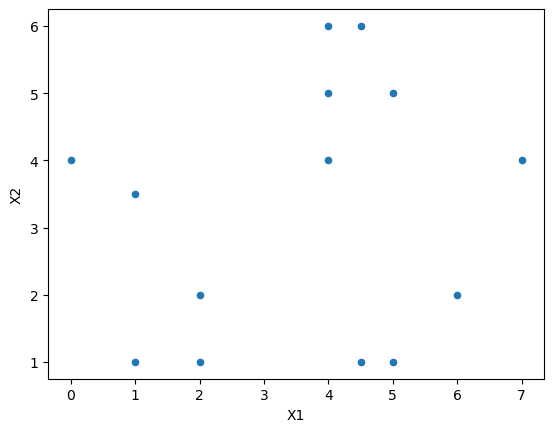

In [11]:
data_2D.plot.scatter("X1", "X2")

### Normalisation des données

<font size="+1" color="RED"><b>[Q]</b></font> Donner les instructions permettant d'afficher les valeurs minimales et maximales de chaque colonne du dataframe `base_2D`.

*Remarque* : Il faut que ces instructions restent valables quel que soit le dataframe donné (noms et nombre de colonnes non connus au départ par exemple).

In [249]:
minX1 = data_2D["X1"].min()
maxX1 = data_2D["X1"].max()

minX2 = data_2D["X2"].min()
maxX2 = data_2D["X2"].max()

print("Minimum et maximum de chaque colonne:")
print("colunm X1:", minX1, maxX1)
print("colunm X2:", minX2, maxX2)

Minimum et maximum de chaque colonne:
colunm X1: 0.0 1.0
colunm X2: 0.0 1.0


<font size="+1" color="RED"><b>[Q]</b></font> En utilisant le minimum et le maximum de chaque variable, et en se référant à la méthode de normalisation présentée au cours 9, écrire la fonction <code>normalisation</code> qui prend en argument un <code>DataFrame</code> et rend le dataframe obtenu en normalisant chaque colonne de ce <code>DataFrame</code> (ie. les valeurs de la matrice résultat doivent être dans l'intervalle $[0,1])$.


In [251]:
from pandas.api.types import is_numeric_dtype

def normalisation(df):
    for column in df.columns:
        if is_numeric_dtype( df[column].dtype ):
            minCol = df[column].min()
            maxCol = df[column].max()
            df[column] = (df[column] - minCol) / (maxCol- minCol)
    return df
    

<font size="+1" color="RED"><b>[Q]</b></font> Normaliser les données de la base-2D et vérifier, par un affichage graphique, que les points sont placés de façon identique qu'avant la normalisation.

<AxesSubplot: xlabel='X1', ylabel='X2'>

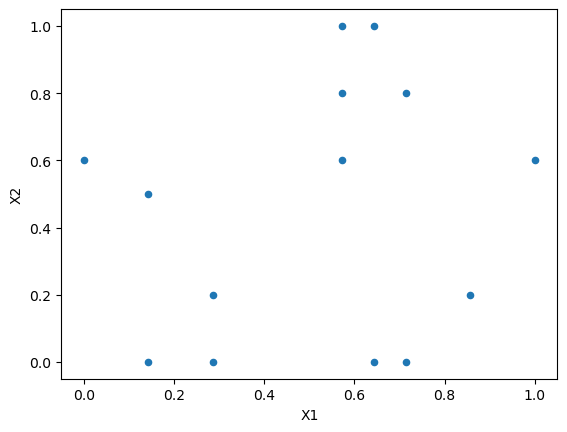

In [252]:
data_2D_norm = normalisation(data_2D)

X1_values = data_2D_norm["X1"]
X2_values = data_2D_norm["X2"]


data_2D_norm.plot.scatter("X1", "X2")

### Distances entre exemples

Comme vu en cours, il y a différentes mesures de distance existantes, la plus utilisée est la distance euclidienne.
Pour écrire un code générique, on définit une classe abstraite `Distance` qui donnera lieu, par héritage, à différentes mesures de distance que l'on souhaitera utiliser.


In [26]:
from abc import ABC, abstractmethod

class Distance(ABC):
    """ Classe abstraite pour représenter des mesures de distances
        Elle permet de définir une hiérarchie pour les distances
    """
    def __init__(self,nom):
        """ Constructeur:
            prend en argument le nom (str) de la distance créé
        """
        self.__nom:str = nom
        
    @abstractmethod
    def calcule(self, v, M):
        """ Arguments:
                - v: un vecteur 
                - M: un vecteur ou une matrice 
            Hypothèse: v et M ont le même nombre de colonnes
            Retour:
                - un float si M est une vecteur: distance entre v et M
                - une np.series si M est une matrice: distances entre le vecteur v et chaque vecteur de M
        """
        # le calcul de distance dépend de la mesure que l'on utilise, il sera implémenté
        # dans les sous-classes de cette classe.
        pass
        
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        return "Distance "+self.__nom
    

#### Distance euclidienne

La distance euclidienne est la distance la plus utilisée, on définit donc une classe pour l'implémenter.

<font size="+1" color="RED"><b>[Q]</b></font> Compléter la classe `DistanceEuclidienne` donnée ci-dessous.
Pour la fonction `calcule`, il est demandé qu'elle puisse:
- calculer la distance entre 2 vecteurs, et rendre dans ce cas une valeur réelle correspondant à cette distance
- calculer la distance entre 1 vecteur et un ensemble de vecteurs donnés sous la forme d'une matrice (dont chaque ligne correspond à un vecteur).
Pour simplifier, on fait l'hypothèse que les 2 arguments sont compatibles en nombre de colonnes.

In [159]:
class DistanceEuclidienne(Distance):
    """ Classe représentant la distance euclidienne
    """
    def __init__(self):
        """ Constructeur
        """
        super().__init__("euclidienne")
        
    def calcule(self, v, M):
        """ Arguments:
                - v: un vecteur 
                - M: un vecteur ou une matrice
            Hypothèse: v et M ont le même nombre de colonnes
            Retour:
                - un float si M est une vecteur: distance entre v et M
                - une np.series si M est une matrice: distances entre le vecteur v et chaque vecteur de M
        """
        if v.ndim != 1:
            raise TypeError("Argument incorrect: le premier argument doit être un vecteur")

        if len(M.shape) == 1:
            return np.linalg.norm((M - v).to_numpy(), axis=0)

        e = (M-v)**2
        return np.sqrt(np.sum((M-v)**2, axis=1))
        
        
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        return super().__str__()

    

In [160]:
# Exemples d'utilisation :
distEuclidienne = DistanceEuclidienne()

# distance entre 2 vecteurs:
v1= data_2D_norm.iloc[0]
v2= data_2D_norm.iloc[1]
print("v1 : ",v1, "\nv2 : ",v2)
val = distEuclidienne.calcule(v1,v2)
print(f"{distEuclidienne} entre v1 et v2 :  \n{val}\n")

v1 :  X1    0.0
X2    0.6
Name: 0, dtype: float64 
v2 :  X1    0.142857
X2    0.500000
Name: 1, dtype: float64
Distance euclidienne entre v1 et v2 :  
0.17437936593905287



In [161]:
# distance entre 1 vecteur et une matrice:
v1= data_2D_norm.iloc[0]
v2= data_2D_norm.iloc[1:]
print("v1 : ",v1, "\nv2 : ",v2)
val = distEuclidienne.calcule(v1,v2)
print(f"{distEuclidienne} entre v1 et v2 :  \n{val}\n")

v1 :  X1    0.0
X2    0.6
Name: 0, dtype: float64 
v2 :            X1   X2
1   0.142857  0.5
2   0.142857  0.0
3   0.285714  0.0
4   0.285714  0.2
5   0.571429  0.6
6   0.571429  0.8
7   0.571429  1.0
8   0.642857  0.0
9   0.642857  1.0
10  0.714286  0.0
11  0.714286  0.8
12  0.857143  0.2
13  1.000000  0.6
Distance euclidienne entre v1 et v2 :  
1     0.174379
2     0.616772
3     0.664554
4     0.491561
5     0.571429
6     0.605418
7     0.697517
8     0.879355
9     0.757143
10    0.932847
11    0.741757
12    0.945883
13    1.000000
dtype: float64



### Distance entre groupes

Dans la CAH, il est nécessaire de calculer la distance entre des groupes d'exemples. Comme vu en cours, la façon de calculer dépend du mode de *linkage* choisi. Il y a 4 grands modes de linkage: complet, simple, moyen et centroïde.

Pour représenter les mesures de distance entre groupe selon le linkage, on définit une classe abstraite `Linkage` qui sera étendue par héritage pour chacun des modes de linkage.


In [162]:
from abc import ABC, abstractmethod

class Linkage(ABC):
    """ Classe abstraite pour représenter des approches Linkage
    """
    def __init__(self,nom):
        """ Constructeur:
            prend en argument:
                - nom (str) du linkage
        """
        self.__nom: str = nom
        
    @abstractmethod
    def calcule(self, G1, G2, verbose= False):
        """ Arguments:
                - G1 et G2 sont des dataframes ou des np.array
                - verbose: pour afficher des messages de débuggage si besoin
            Hypothèse: 
                - G1 et G2 ont le même nombre de colonnes
            Retour:
                - la distance entre G1 et G2 selon le linkage
        """
        pass
        
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        return "Linkage "+self.__nom

    

<font size="+1" color="RED"><b>[Q]</b></font> Compléter la classe `LinkageComplete` donnée ci-dessous.
Cette classe permet d'implémenter l'approche *Complete Linkage*.
Ce linkage est associée à une mesure de distance qui est donnée à la création de l'objet, par défaut, on utilise la distance euclidienne.

La fonction `calcule` prend 2 groupes d'exemples et calcule leur distance, selon le mode *Complete linkage*, en utilisant la distance donnée pour calculer la distance entre 2 exemples.

In [163]:
class LinkageComplete(Linkage):
    """ Classe pour le linkage "Complete"
    """
    def __init__(self,distance=DistanceEuclidienne()):
        """ Constructeur:
            prend en argument:
                - nom (str) du linkage
                - distance (Distance): mesure de distance entre 2 exemples
                  par défaut: distance euclidienne
        """
        super().__init__("complete")
        self.__distance = distance
        
    def calcule(self, G1, G2,verbose=False):
        """ Arguments:
                - G1 et G2 sont des dataframes ou des np.array
                - verbose: pour afficher des messages de débuggage si besoin
            Hypothèse: 
                - G1 et G2 ont le même nombre de colonnes
            Retour:
                - la distance entre G1 et G2 selon le linkage
        """

        if len(G1.shape) == 1:
            return np.max(self.__distance.calcule(G1, G2))

        if len(G2.shape) == 1:
            return np.max(self.__distance.calcule(G2, G1))
            
        res = -1.0
        for i in range(len(G1)):
            dist = np.max(self.__distance.calcule(G1.iloc[i], G2))
            res = max(res, float(dist))
        return res

        
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        return super().__str__()+ " ("+self.__distance.__str__()+")"
    

In [164]:
# Exemple d'utilisation :

# Groupes avec chacun 1 seul exemple:
G1df = data_2D_norm.iloc[0]
G2df = data_2D_norm.iloc[5]

linkComplete = LinkageComplete()

print(f"G1(1) et G2(1)\t---> Distance : {linkComplete.calcule(G1df,G2df,verbose=False)}")

# Exemple d'utilisation :

# G1 avec 1 exemple et G2 avec plusieurs:
G1df = data_2D_norm.iloc[0]
G2df = data_2D_norm.iloc[5:]

linkComplete = LinkageComplete()
valeur = linkComplete.calcule(G1df,G2df,verbose=False)
print(f"G1(1) et G2 (+)\t---> Distance : {valeur}")

# Exemple d'utilisation :

# G1 avec plusieurs exemples et G2 avec 1 seul:
G1df = data_2D_norm.iloc[0:4]
G2df = data_2D_norm.iloc[5]

linkComplete = LinkageComplete()
valeur = linkComplete.calcule(G1df,G2df,verbose=False)
print(f"G1(+) et G2(1)\t---> Distance : {valeur}")

# Exemple d'utilisation :

# G1 avec plusieurs exemples et G2 avec plusieurs exemples aussi:
G1df = data_2D_norm.iloc[0:4]
G2df = data_2D_norm.iloc[5:]

linkComplete = LinkageComplete()
valeur = linkComplete.calcule(G1df,G2df,verbose=False)
print(f"G1(+) et G2(+)\t---> Distance : {valeur}")


G1(1) et G2(1)	---> Distance : 0.5714285714285714
G1(1) et G2 (+)	---> Distance : 1.0
G1(+) et G2(1)	---> Distance : 0.7373421657465108
G1(+) et G2(+)	---> Distance : 1.118033988749895


<font size="+1" color="RED"><b>[Q]</b></font> Compléter les classes `LinkageSimple`, `LinkageAverage` et `LinkageCentroide` sur le modèle de la classe `LinkageComplete`.

In [172]:
class LinkageSimple(Linkage):
    """ Classe pour le linkage "Simple"
    """
    def __init__(self,distance=DistanceEuclidienne()):
        """ Constructeur:
            prend en argument:
                - nom (str) du linkage
                - distance (Distance): mesure de distance entre 2 exemples
                  par défaut: distance euclidienne
        """
        super().__init__("simple")
        self.__distance = distance
        
    def calcule(self, G1, G2,verbose=False):

        if len(G1.shape) == 1:
            return np.min(self.__distance.calcule(G1, G2))

        if len(G2.shape) == 1:
            return np.min(self.__distance.calcule(G2, G1))
            
        res = 2**64-1
        for i in range(len(G1)):
            dist = np.min(self.__distance.calcule(G1.iloc[i], G2))
            res = min(res, float(dist))
        return res
        
# ------------------------------------------------------
class LinkageAverage(Linkage):
    """ Classe pour le linkage "Average"
    """
    def __init__(self,distance=DistanceEuclidienne()):
        """ Constructeur:
            prend en argument:
                - nom (str) du linkage
                - distance (Distance): mesure de distance entre 2 exemples
                  par défaut: distance euclidienne
        """
        super().__init__("average")     
        self.__distance = distance
        
    def calcule(self, G1, G2,verbose=False):

        if len(G1.shape) == 1:
            return np.mean(self.__distance.calcule(G1, G2))

        if len(G2.shape) == 1:
            return np.mean(self.__distance.calcule(G2, G1))

        return np.mean(np.array([np.mean(self.__distance.calcule(G1.iloc[i], G2)) for i in range(len(G1))]))

# ------------------------------------------------------
class LinkageCentroide(Linkage):
    """ Classe pour le linkage "Centroide"
    """
    def __init__(self,distance=DistanceEuclidienne()):
        """ Constructeur:
            prend en argument:
                - nom (str) du linkage
                - distance (Distance): mesure de distance entre 2 exemples
                  par défaut: distance euclidienne
        """
        super().__init__("centroide")
        self.__distance = distance    
        
    def calcule(self, G1, G2,verbose=False):

        if len(G1.shape) == 1 and len(G2.shape) == 1:
            return self.__distance.calcule(G1, G2)

        if len(G1.shape) == 1:
            return self.__distance.calcule(G1, np.mean(G2, axis=0))

        if len(G2.shape) == 1:
            return self.__distance.calcule(G2, np.mean(G1, axis=0))

        return self.__distance.calcule(np.mean(G2, axis=0), np.mean(G1, axis=0))

# ------------------------------------------------------
    

In [173]:
# Exemple d'utilisation :

les_linkages = [LinkageComplete(), LinkageSimple(), LinkageAverage(), LinkageCentroide()]

# Groupes avec chacun 1 seul exemple:
G1df = data_2D_norm.iloc[0]
G2df = data_2D_norm.iloc[5]
print("G1(1) et G2(1):")
for lk in les_linkages:
    print(f"\t---> {lk}\t: {lk.calcule(G1df,G2df,verbose=False):1.4f}")

# Exemple d'utilisation :

# G1 avec 1 exemple et G2 avec plusieurs:
G1df = data_2D_norm.iloc[0]
G2df = data_2D_norm.iloc[5:]
print("G1(1) et G2(+):")
for lk in les_linkages:
    print(f"\t---> {lk}\t: {lk.calcule(G1df,G2df,verbose=False):1.4f}")


# Exemple d'utilisation :

# G1 avec plusieurs exemples et G2 avec 1 seul:
G1df = data_2D_norm.iloc[0:4]
G2df = data_2D_norm.iloc[5]
print("G1(+) et G2(1):")
for lk in les_linkages:
    print(f"\t---> {lk}\t: {lk.calcule(G1df,G2df,verbose=False):1.4f}")


# Exemple d'utilisation :

# G1 avec plusieurs exemples et G2 avec plusieurs exemples aussi:
G1df = data_2D_norm.iloc[0:4]
G2df = data_2D_norm.iloc[5:]
print("G1(+) et G2(+):")
for lk in les_linkages:
    print(f"\t---> {lk}\t: {lk.calcule(G1df,G2df,verbose=False):1.4f}")


G1(1) et G2(1):
	---> Linkage complete (Distance euclidienne)	: 0.5714
	---> Linkage simple	: 0.5714
	---> Linkage average	: 0.5714
	---> Linkage centroide	: 0.5714
G1(1) et G2(+):
	---> Linkage complete (Distance euclidienne)	: 1.0000
	---> Linkage simple	: 0.5714
	---> Linkage average	: 0.7924
	---> Linkage centroide	: 0.6998
G1(+) et G2(1):
	---> Linkage complete (Distance euclidienne)	: 0.7373
	---> Linkage simple	: 0.4401
	---> Linkage average	: 0.6034
	---> Linkage centroide	: 0.5379
G1(+) et G2(+):
	---> Linkage complete (Distance euclidienne)	: 1.1180
	---> Linkage simple	: 0.3571
	---> Linkage average	: 0.7709
	---> Linkage centroide	: 0.6224


### Algorithme de classification hiérarchique ascendante 


Dans la suite, une partition (qui est un groupe de clusters) est représentée par un dictionnaire Python:
- la clé est un numéro de cluster (entier naturel) ;
- la valeur associée est une liste contenant les indices des exemples du dataset qui sont dans le cluster correspondant.

Les indices sont ceux du dataframe qui contient la base initiale.

<b>Dans ce qui suit, on appelle "partition" un tel dictionnaire.</b>


<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>CHA_initialise</code> qui, étant donné un dataframe DF représentant une base d'apprentissage, rend une partition contenant autant d'entrées que d'exemples dans DF. La clé de chaque entrée est le numéro de l'exemple. Cette fonction est spécifique à la classification hiérarchique ascendante (CHA).

In [178]:
def CHA_initialise(df):
    return {i:[i] for i in range(len(data_2D_norm))}

In [179]:
# Par exemple:
depart = CHA_initialise(data_2D_norm)
depart

{0: [0],
 1: [1],
 2: [2],
 3: [3],
 4: [4],
 5: [5],
 6: [6],
 7: [7],
 8: [8],
 9: [9],
 10: [10],
 11: [11],
 12: [12],
 13: [13]}

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>CHA_fusionne</code> qui prend en argument:
- un dataframe contenant des exemples
- une partition P0
- une instance de Linkage
- l'indicateur verbose.

et qui retourne le tuple composé des 4 valeurs suivantes
- la partition P1 obtenue après fusion des 2 clusters de P0 les plus proches selon le linkage donné ;
- les clés des 2 clusters de P0 qui ont été fusionnés et qui ne sont donc plus dans P1 ;
- la distance qui séparait ces 2 clusters.


In [202]:
def CHA_fusionne(df, part, linkage, verbose):
    minDist = 2**64
    part1Cle = None
    part2Cle = None

    p1 = part.copy()
    
    
    for cle1 in part.keys():
        for cle2 in part.keys():
            if cle1 == cle2:
                continue
                
            newDist = linkage.calcule(df.iloc[part[cle1]], df.iloc[part[cle2]], verbose)
            # print(newDist)
            if newDist < minDist:
                minDist = newDist
                part1Cle = cle1
                part2Cle = cle2

    newIndex = max(part.keys())+1
    p1[newIndex] = part[part1Cle] + part[part2Cle]
    p1.pop(part1Cle, None)
    p1.pop(part2Cle, None)
        
    return p1, part1Cle, part2Cle, minDist

In [203]:
# Exemple:
linkComplete = LinkageComplete()
CHA_fusionne(data_2D_norm, depart, linkComplete,verbose=True)

({0: [0],
  1: [1],
  2: [2],
  3: [3],
  4: [4],
  5: [5],
  6: [6],
  7: [7],
  9: [9],
  11: [11],
  12: [12],
  13: [13],
  14: [8, 10]},
 8,
 10,
 0.0714285714285714)

<font size="+1" color="RED"><b>[Q]</b></font> L'algorithme CHA réalise des fusions jusqu'à ce qu'il n'y ait plus qu'un groupe unique dans la partition. 
Ecrire la fonction <code>CHA_algorithme</code> qui prend en argument un dataframe et une instance de Linkage et retourne une liste composée de listes contenant chacune:
- les 2 indices d'éléments fusionnés
- la distance les séparant
- la somme du nombre d'éléments des 2 éléments fusionnés

Dans ce qui suit, on appelle **liste résultat** une telle liste.

Comme pour la fonction précédente, un argument verbose permet d'avoir des messages  lors de l'exécution de la fonction (et de la fonction précédente qu'elle appelle).

Remarque: chaque sous-liste contient donc les 3 dernières valeurs du obtenues lors de l'appel de `CHA_fusionne`.


In [209]:
def CHA_algorithme(df,linkage,verbose):
    part = CHA_initialise(df)
    info = []
    while len(part) > 1:
        p, c1, c2, d = CHA_fusionne(df, part, linkage, verbose)
        part = p
        info.append([c1, c2, d, len(p[max( p.keys() )])] )
    return info

In [210]:
# L'application sur nos données:
CHA_algorithme(data_2D_norm,linkComplete,verbose=False)

[[8, 10, 0.0714285714285714, 2],
 [7, 9, 0.07142857142857151, 2],
 [2, 3, 0.14285714285714285, 2],
 [6, 11, 0.1428571428571429, 2],
 [0, 1, 0.17437936593905287, 2],
 [15, 17, 0.2457807219155036, 4],
 [4, 16, 0.24578072191550362, 3],
 [12, 14, 0.2931183504097598, 3],
 [5, 19, 0.40632750438079696, 5],
 [13, 22, 0.5862367008195198, 6],
 [18, 20, 0.6645544771207432, 5],
 [21, 24, 0.945882591842677, 8],
 [23, 25, 1.118033988749895, 14]]

In [211]:
CHA_algorithme(data_2D_norm,linkComplete,verbose=True)

[[8, 10, 0.0714285714285714, 2],
 [7, 9, 0.07142857142857151, 2],
 [2, 3, 0.14285714285714285, 2],
 [6, 11, 0.1428571428571429, 2],
 [0, 1, 0.17437936593905287, 2],
 [15, 17, 0.2457807219155036, 4],
 [4, 16, 0.24578072191550362, 3],
 [12, 14, 0.2931183504097598, 3],
 [5, 19, 0.40632750438079696, 5],
 [13, 22, 0.5862367008195198, 6],
 [18, 20, 0.6645544771207432, 5],
 [21, 24, 0.945882591842677, 8],
 [23, 25, 1.118033988749895, 14]]

### Construction de dendrogramme

Pour construire le dendrogramme, on utilise une fonction de la librairie `scipy`. Cette fonction prend en premier argument le résultat retourné par notre fonction `CHA_algorithme`.


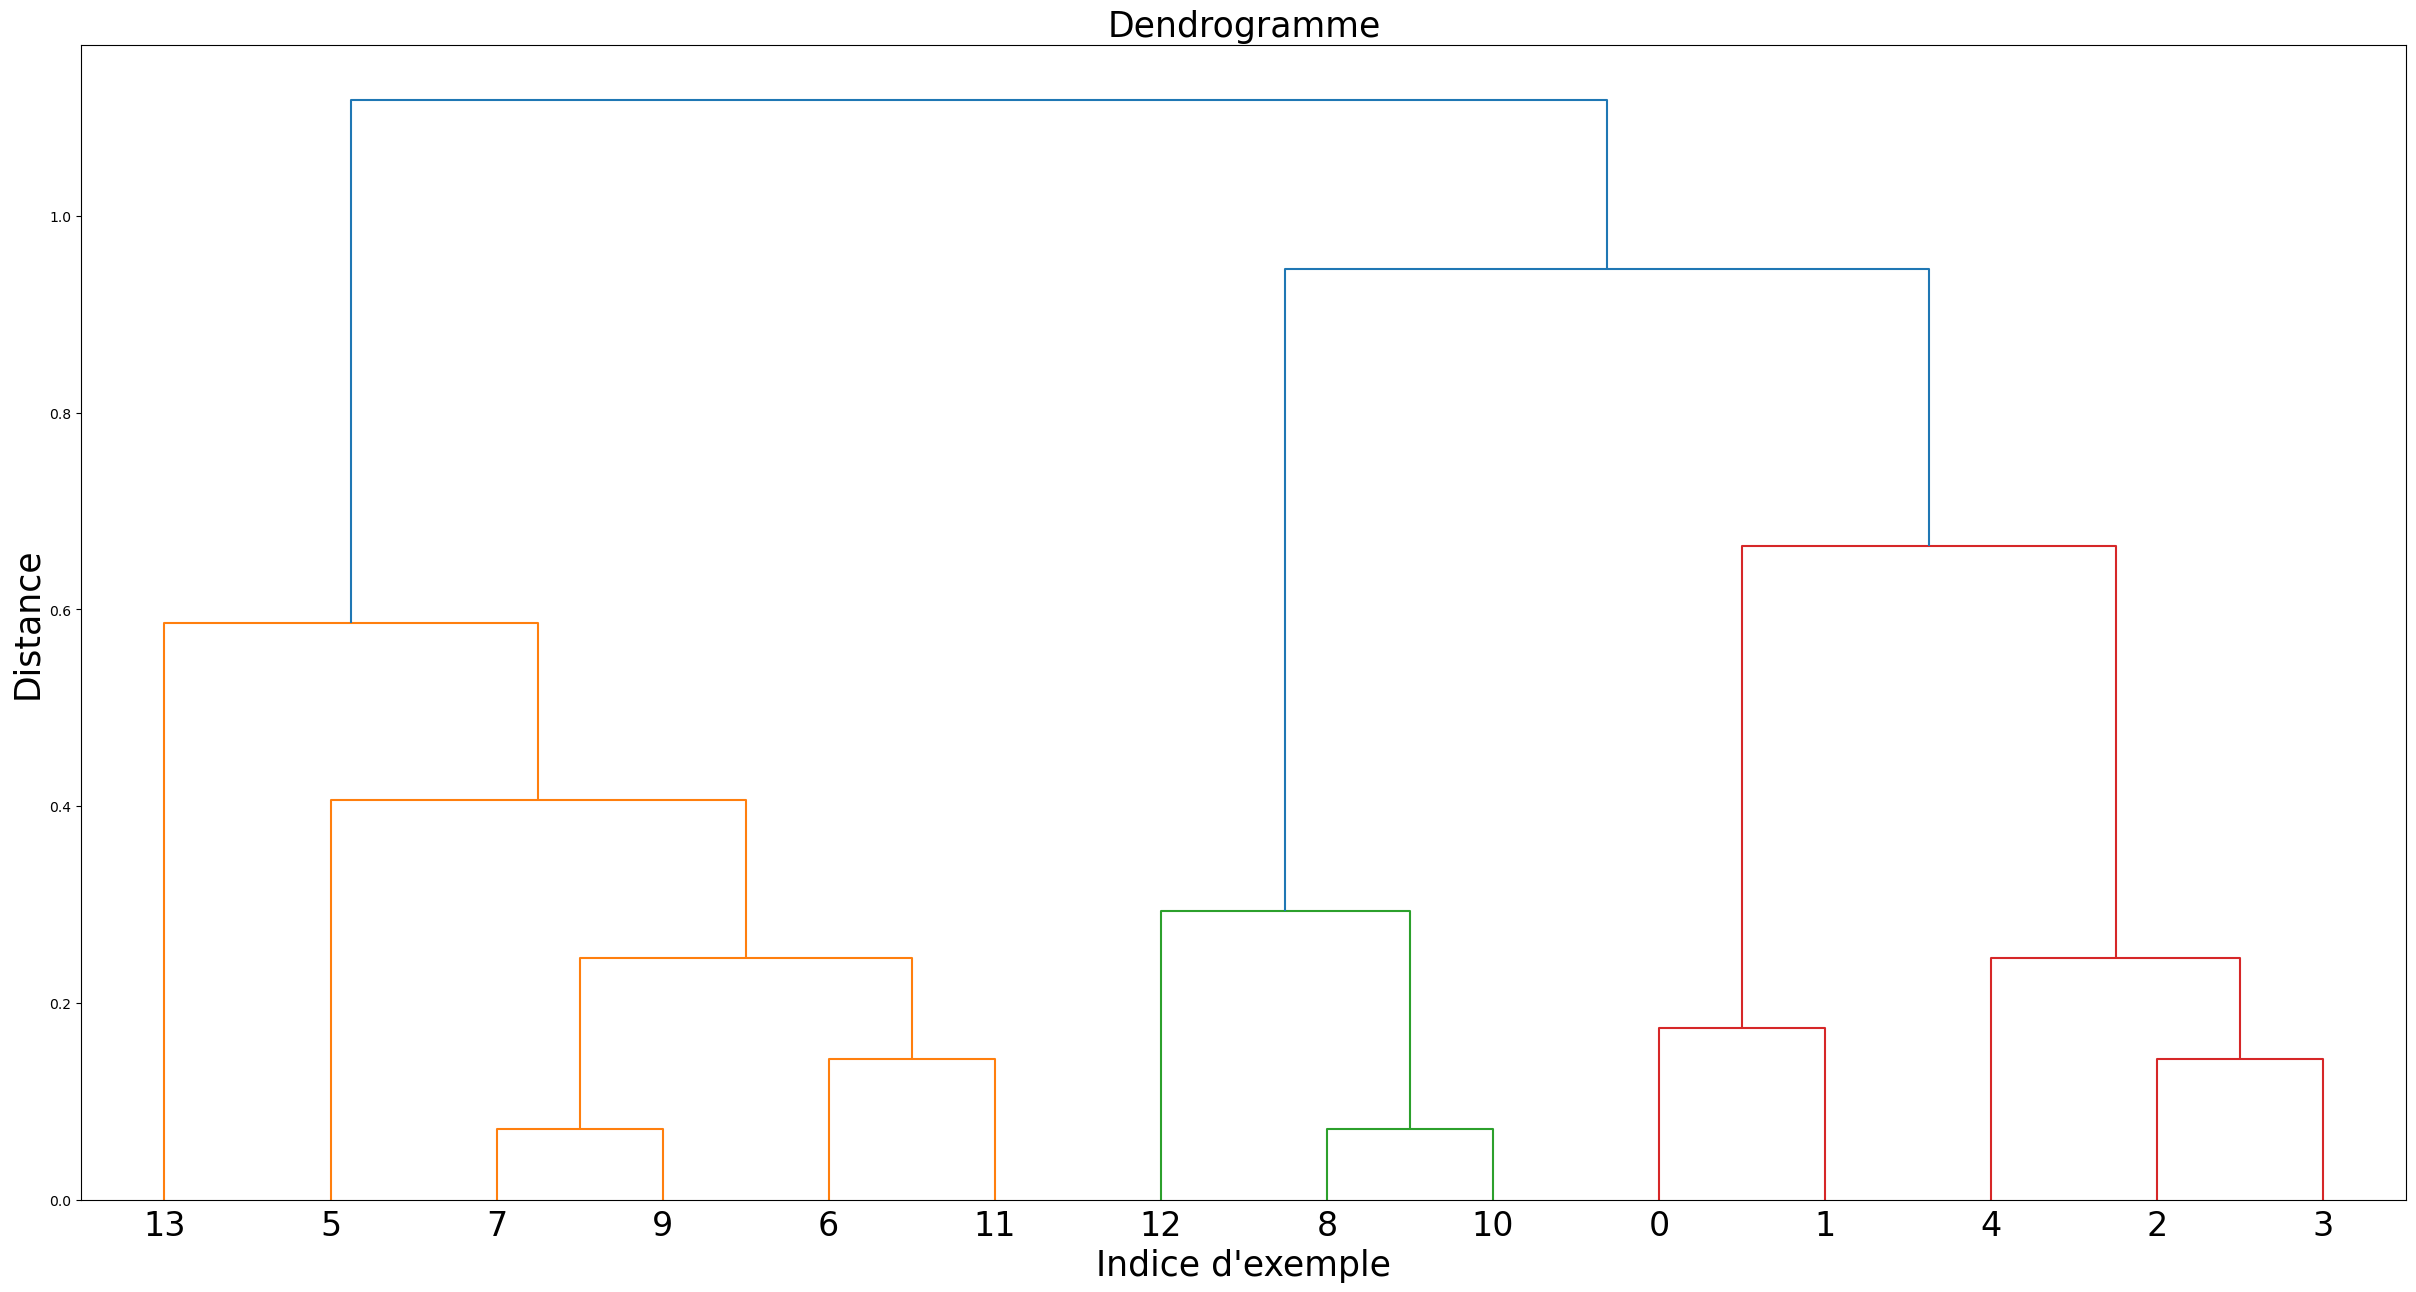

In [212]:
import scipy.cluster.hierarchy

# Paramètre de la fenêtre d'affichage: 
plt.figure(figsize=(30, 15)) # taille : largeur x hauteur
plt.title('Dendrogramme', fontsize=25)    
plt.xlabel("Indice d'exemple", fontsize=25)
plt.ylabel('Distance', fontsize=25)

# Construction du dendrogramme pour notre clustering :
scipy.cluster.hierarchy.dendrogram(
    CHA_algorithme(data_2D_norm,linkComplete,verbose=False), 
    leaf_font_size=24.,  # taille des caractères de l'axe des X
)

# Affichage du résultat obtenu:
plt.show()

<font size="+1" color="RED"><b>[Q]</b></font> Ecrire la fonction <code>CHA_dendrogramme</code> qui prend en argument une liste résultat ainsi qu'une chaîne de caractères donnant les informations sur le linkage et qui affiche le dendrogramme correspondant.



In [218]:
def CHA_dendrogramme(cha_info, linkage):
    # Paramètre de la fenêtre d'affichage: 
    plt.figure(figsize=(30, 15)) # taille : largeur x hauteur
    plt.title('Dendrogramme: ' + str(linkage), fontsize=25)    
    plt.xlabel("Indice d'exemple", fontsize=25)
    plt.ylabel('Distance', fontsize=25)
    
    # Construction du dendrogramme pour notre clustering :
    scipy.cluster.hierarchy.dendrogram(
        cha_info, 
        leaf_font_size=24.,  # taille des caractères de l'axe des X
    )
    
    # Affichage du résultat obtenu:
    plt.show()

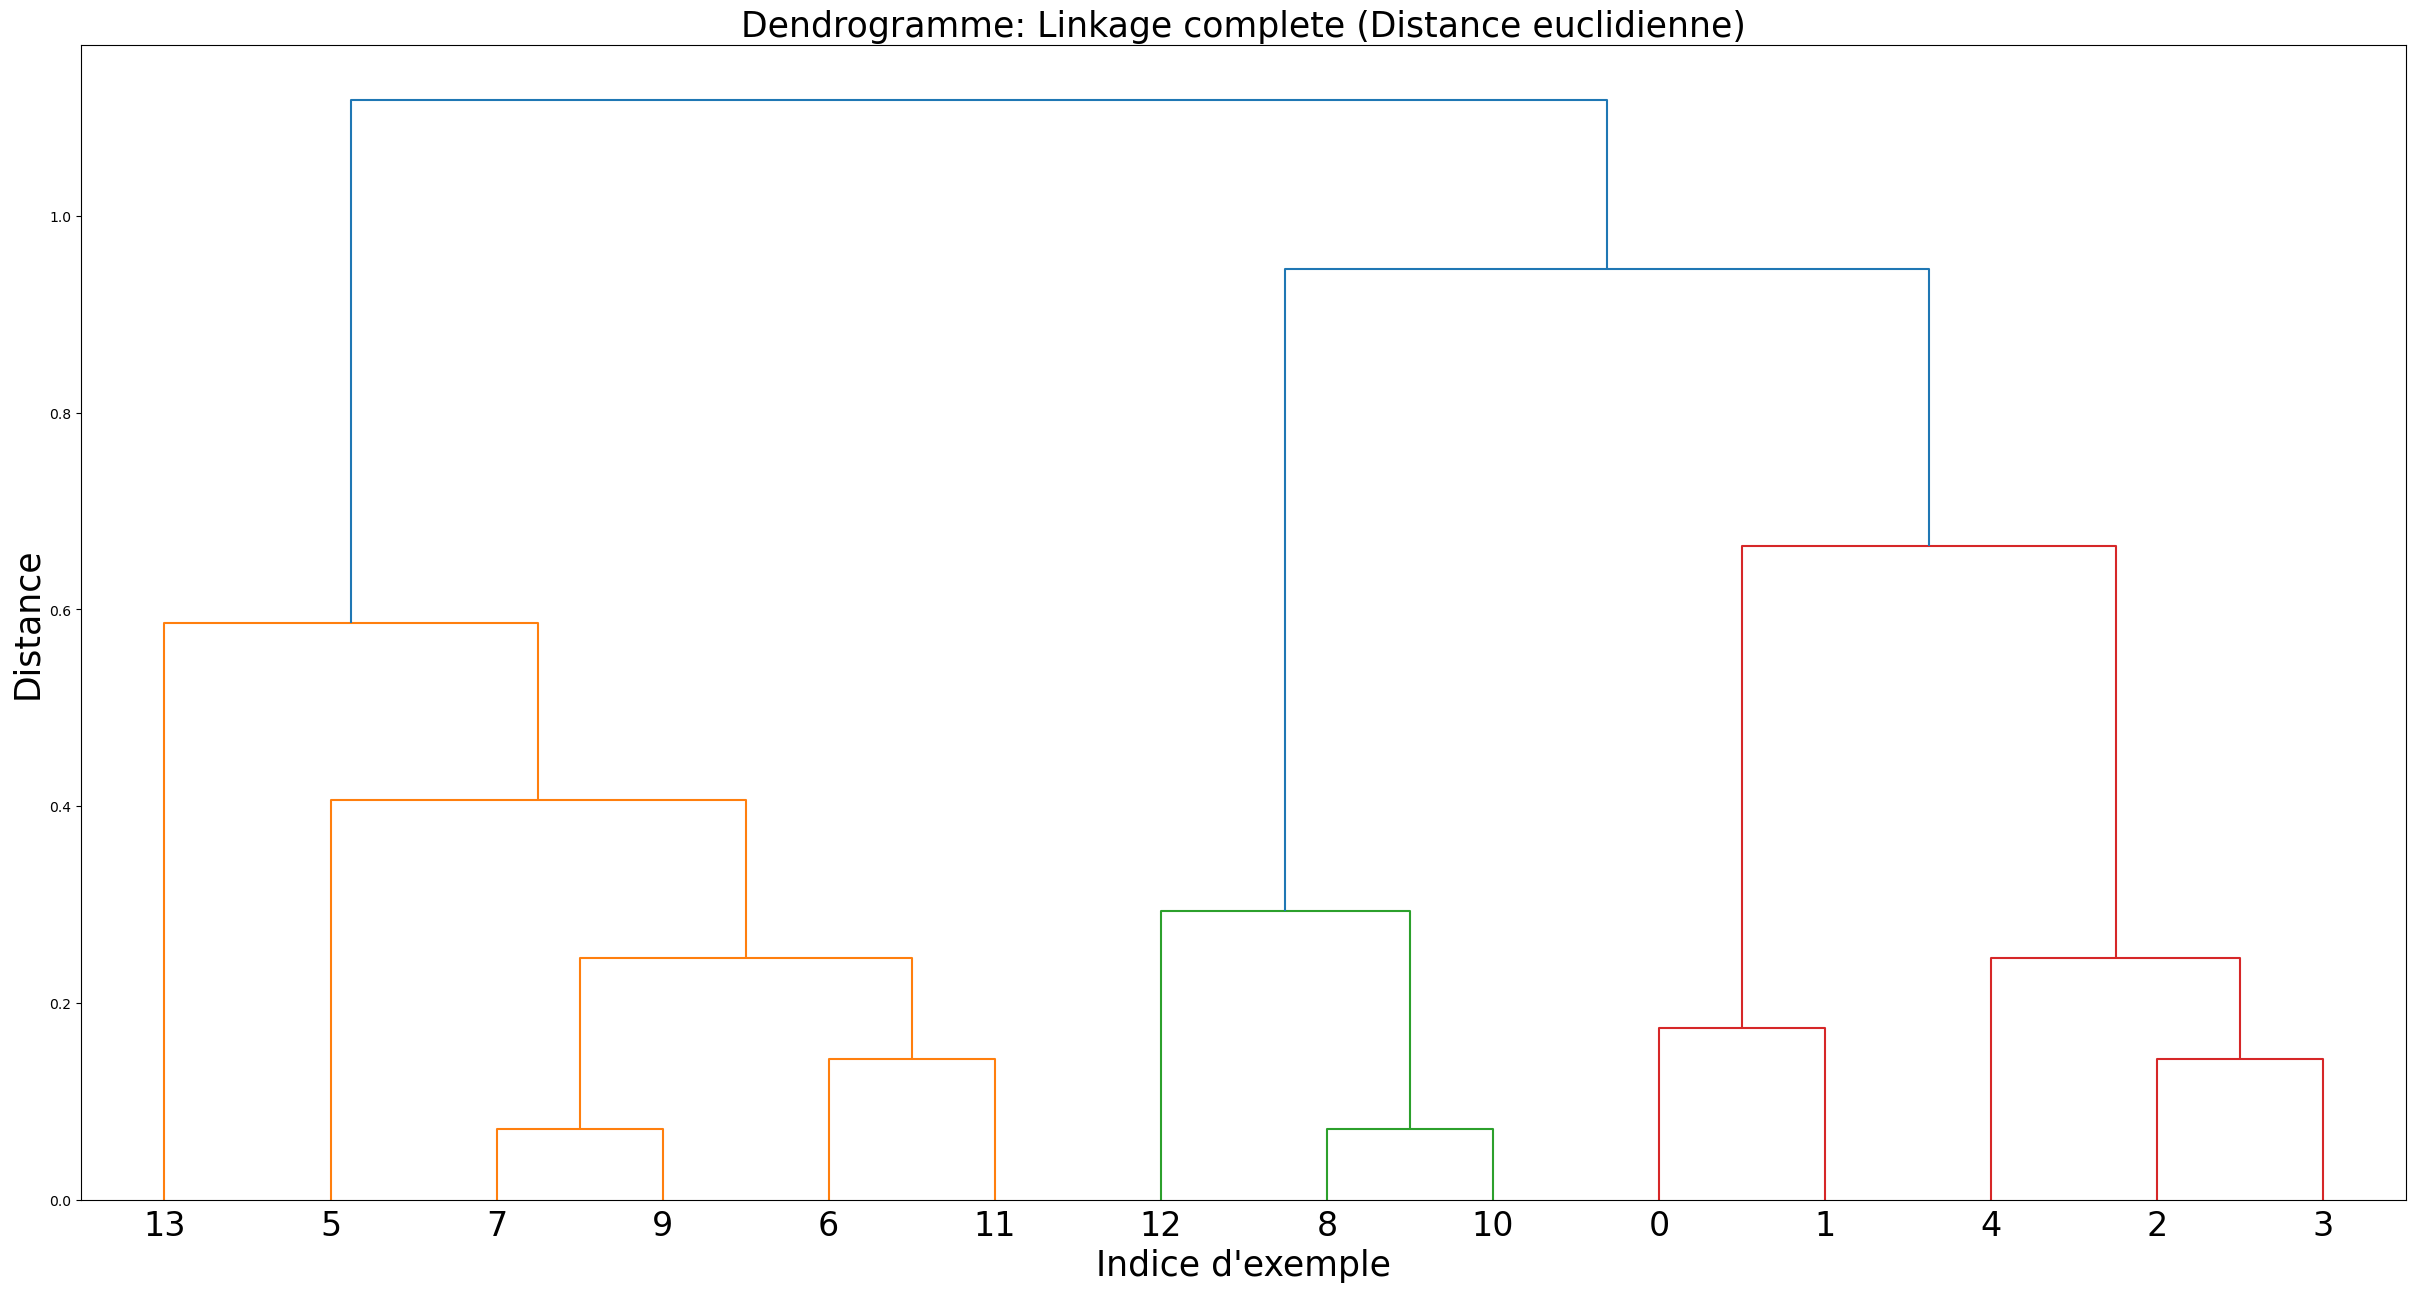

In [219]:
CHA_dendrogramme(CHA_algorithme(data_2D_norm,linkComplete,verbose=False),linkComplete)

### Un autre dataset pour tester

Etudier les différences de résultats obtenus avec chacune des approches de linkage sur la base suivante:
- générer les dendrogrammes et la hiérarchie de partitions pour chaque approche de linkage
- comparer les résultats obtenus

*Remarque:* le linkage centroïde n'est souvent pas adapté aux données à traiter, vous vous concentrerez donc, à partir de maintenant, à des expérimentatiosn n'utilisant que les approches linkage complete, simple et average.

In [220]:
data_2D_diff = normalisation(pd.read_csv("data/base-2D-diff.csv"))

<AxesSubplot: xlabel='X1', ylabel='X2'>

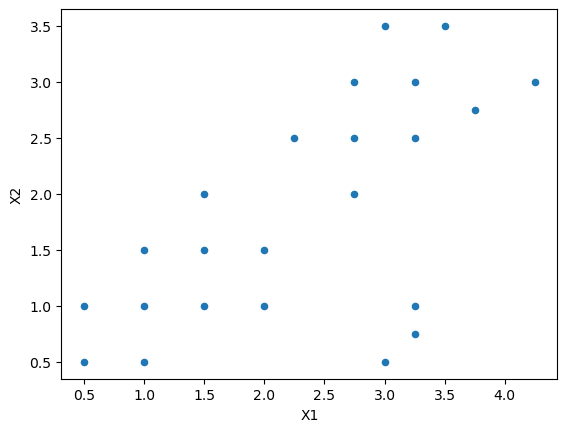

In [221]:

X1_values = data_2D_diff["X1"]
X2_values = data_2D_diff["X2"]


data_2D_diff.plot.scatter("X1", "X2")

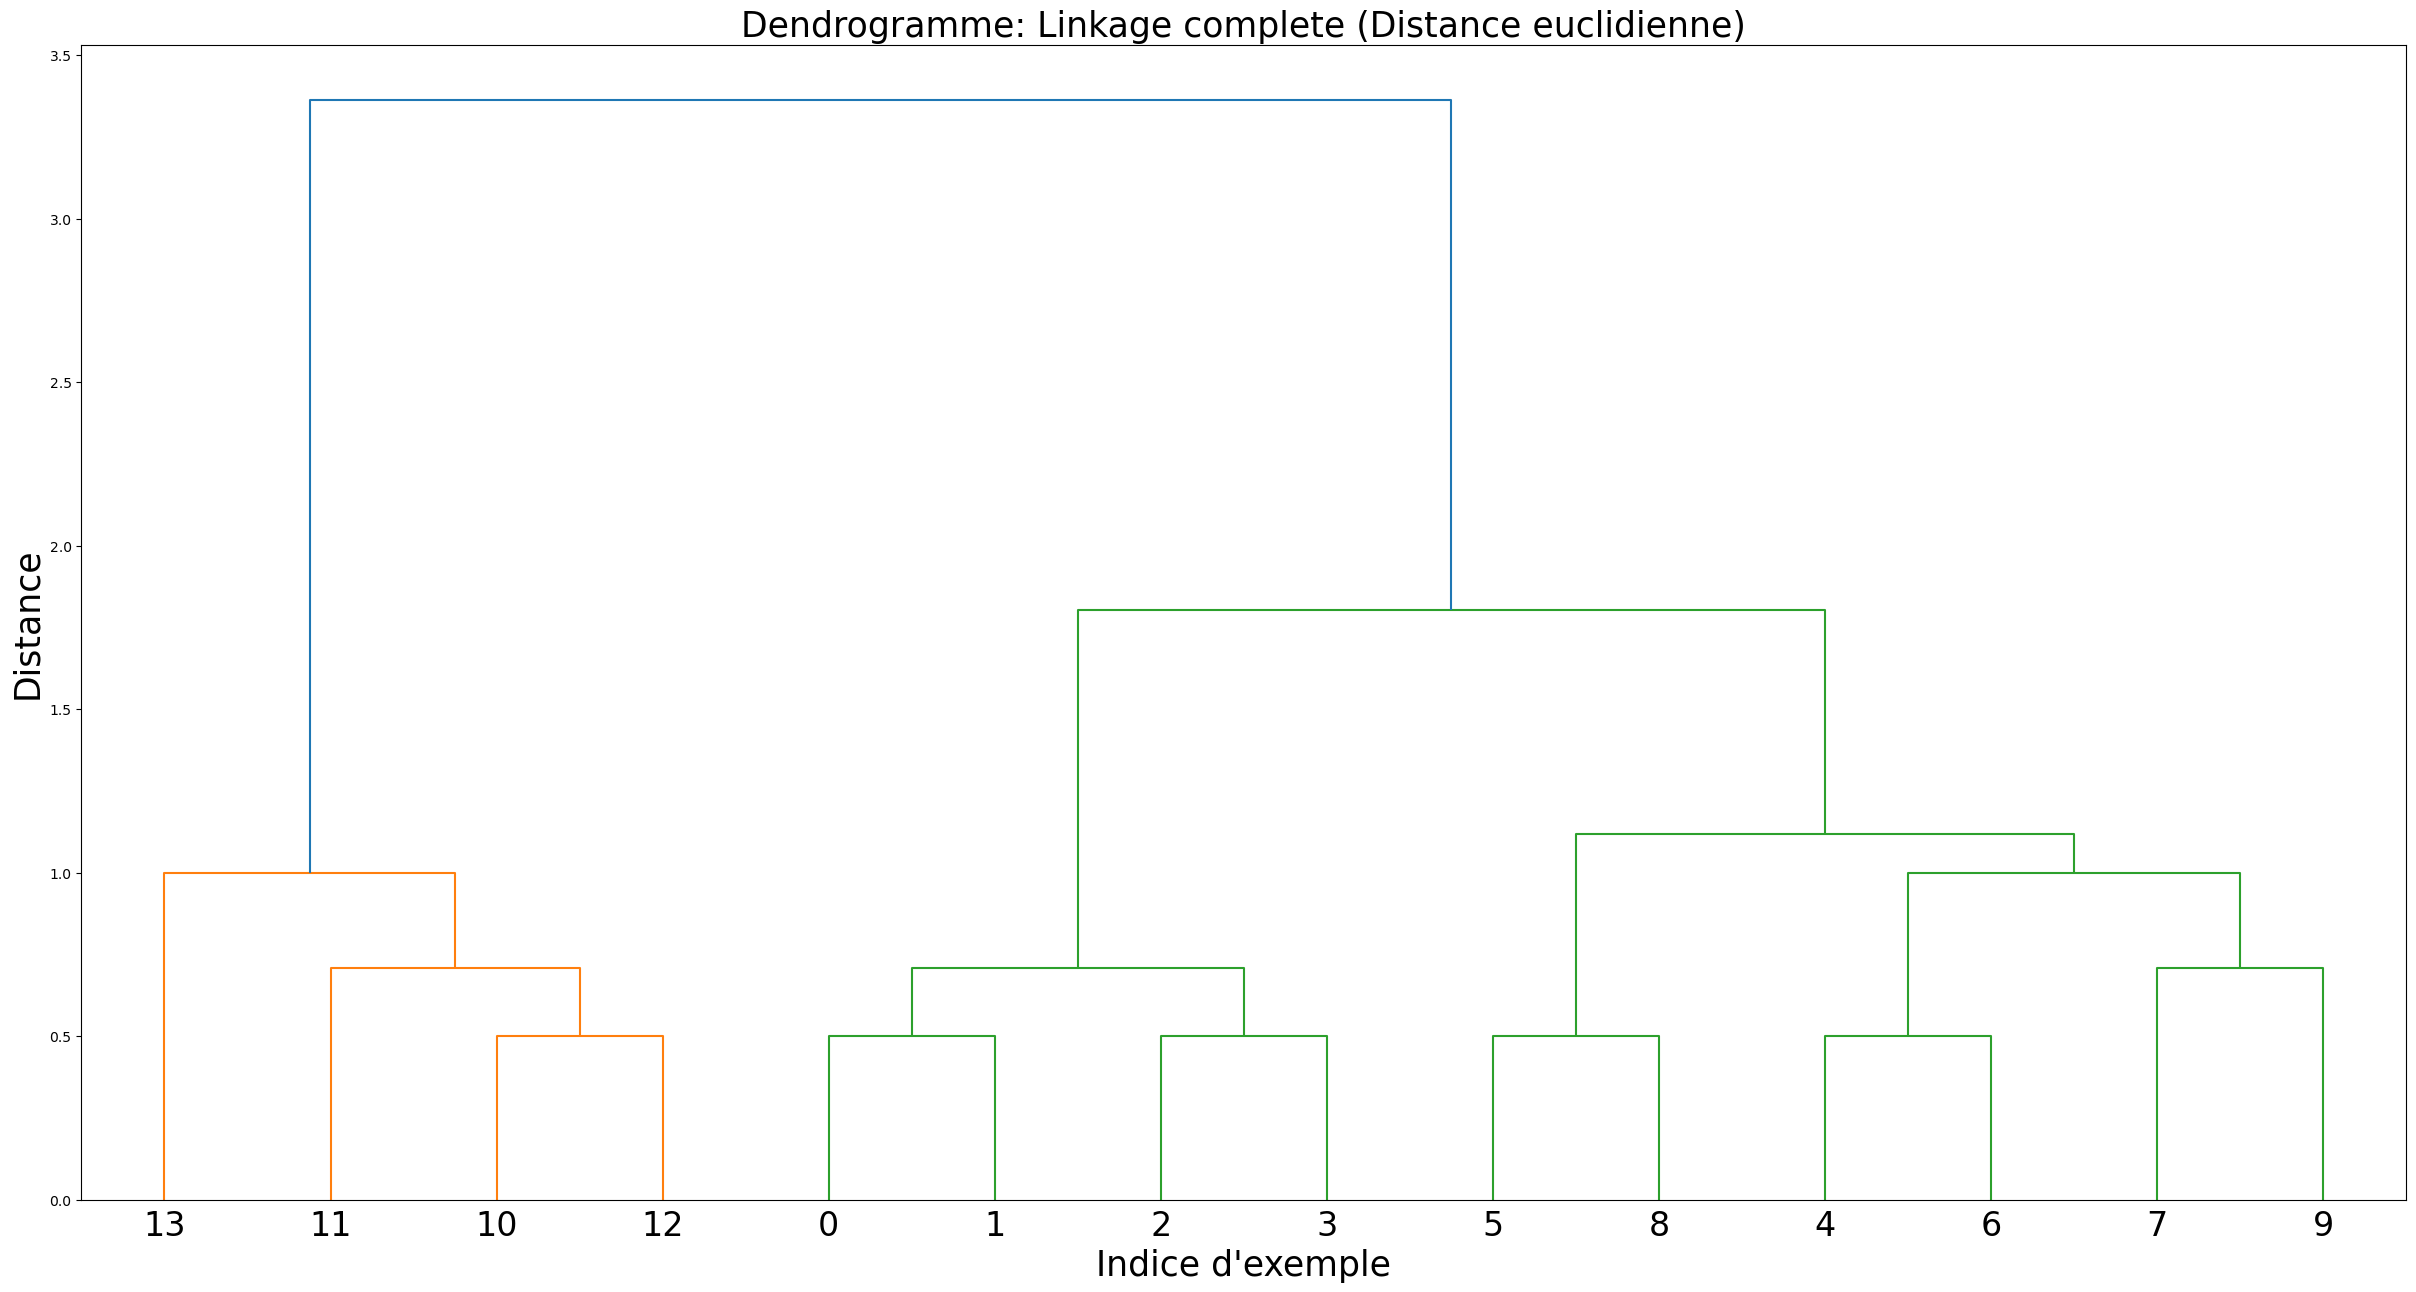

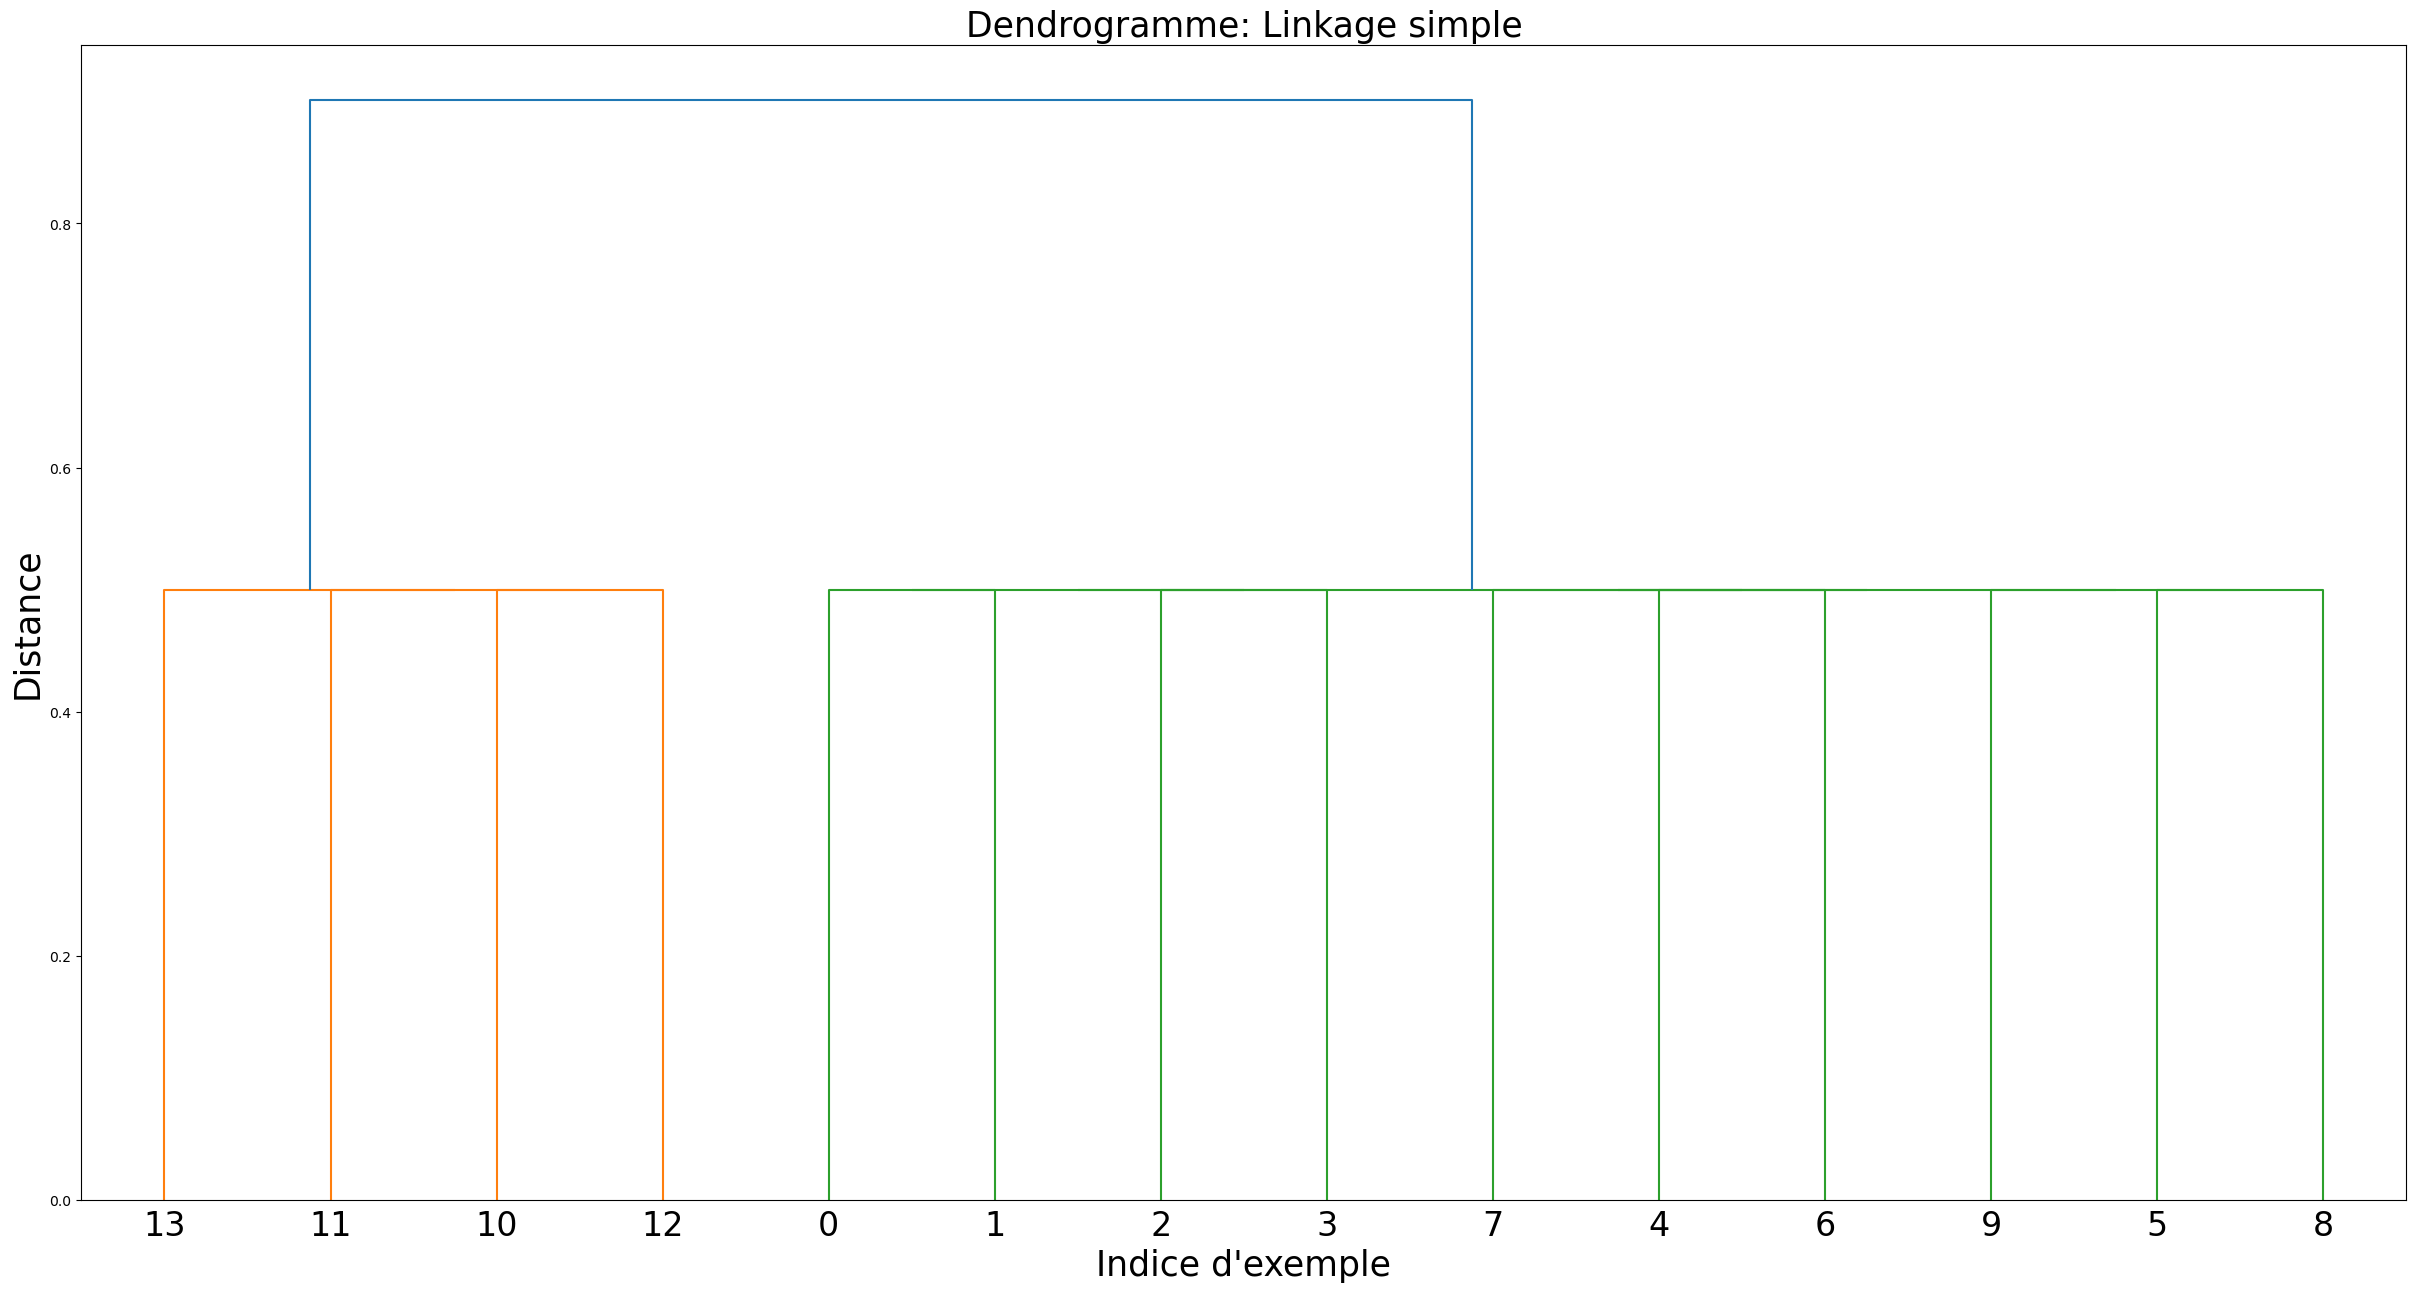

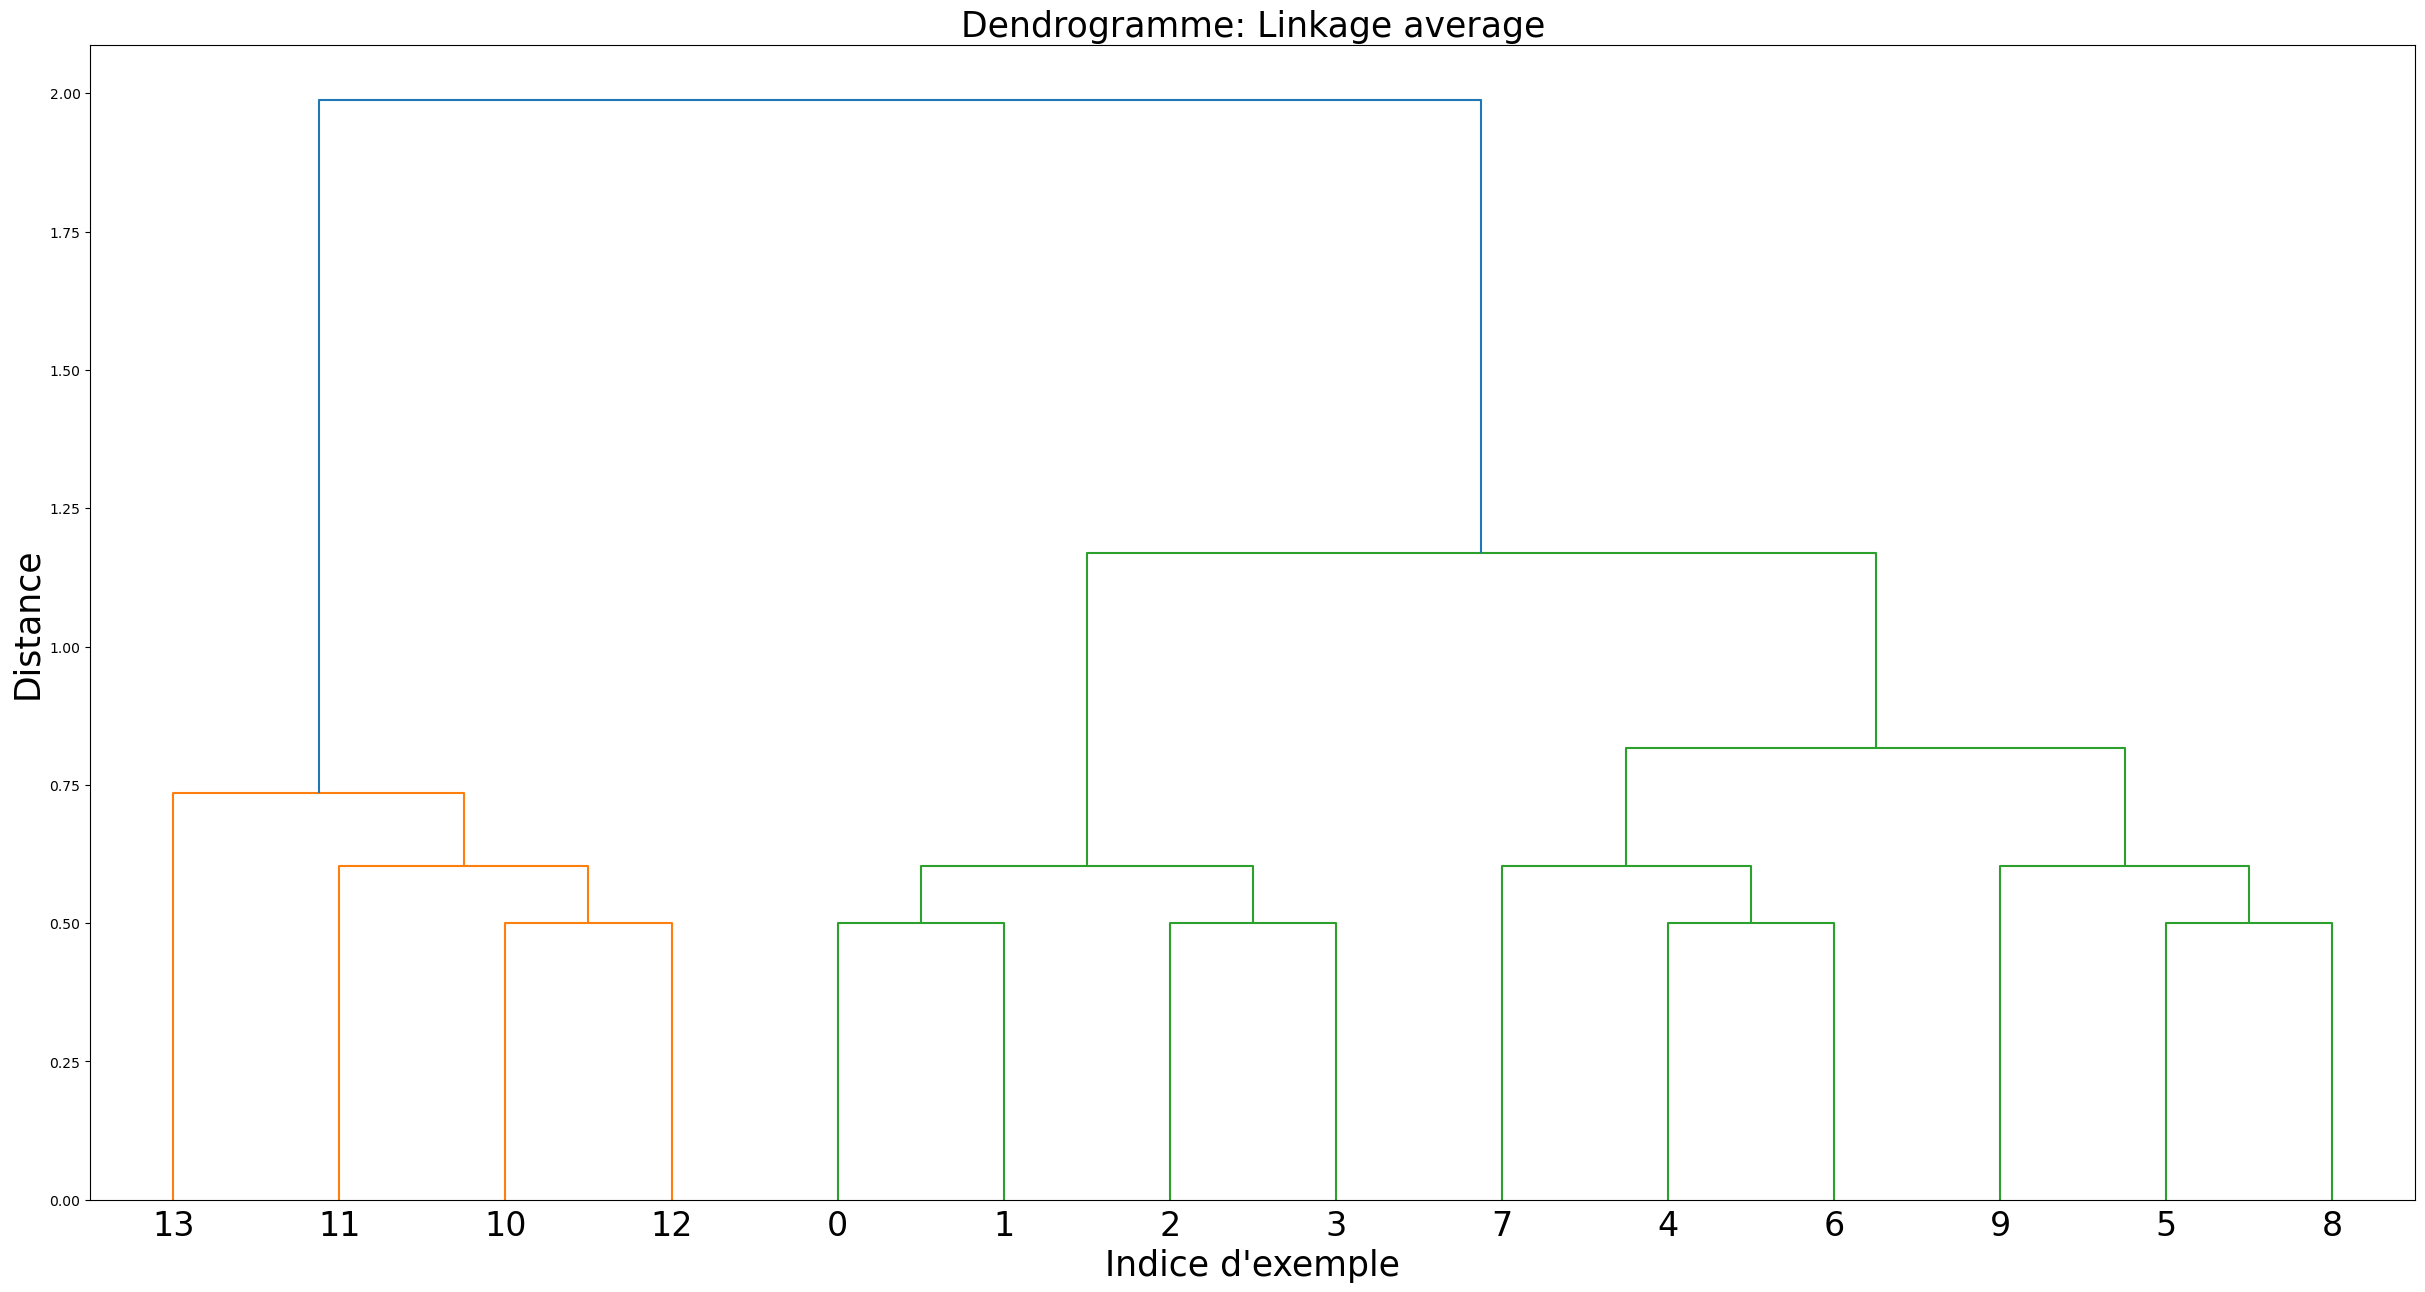

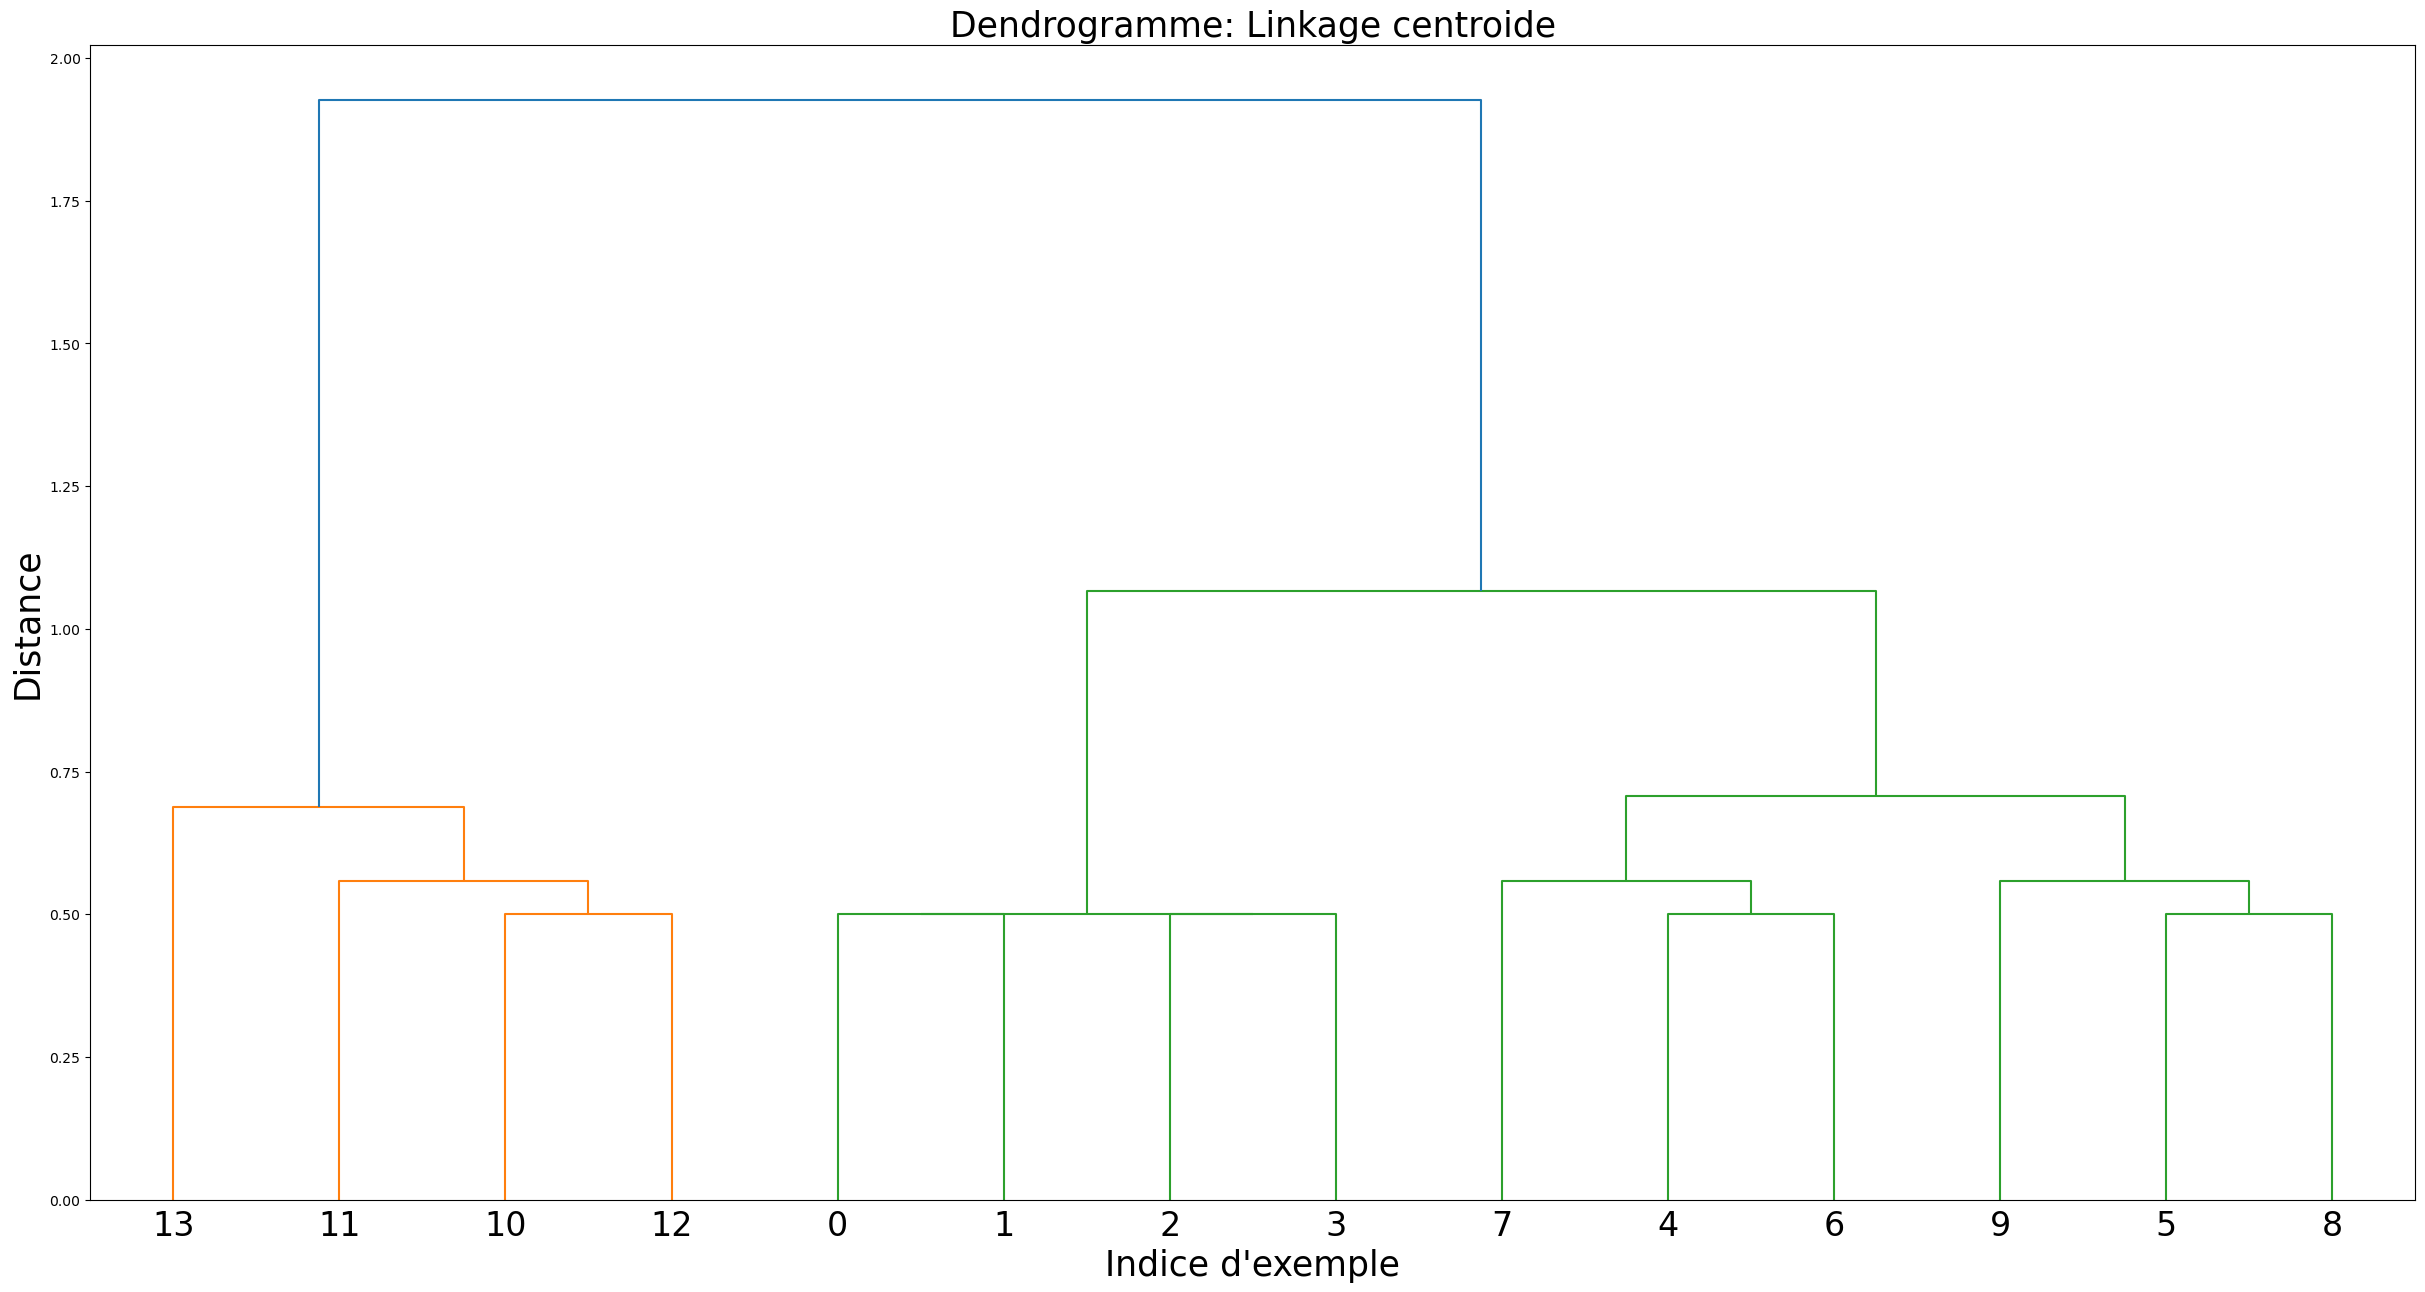

In [222]:
les_linkages = [LinkageComplete(), LinkageSimple(), LinkageAverage(), LinkageCentroide()]

for link in les_linkages:
    CHA_dendrogramme(CHA_algorithme(data_2D_diff,link,verbose=False),link)


<font size="+1" color="RED"><b>[Q]</b></font> En cours il a été présenté différentes mesures de distance, en particulier la distance paramétrée de Minkowski. Ajouter une nouvelle classe `DistanceMinkowski` qui hérite de `Distance`. Pour cette classe, l'initialisation requiert une valeur pour le paramètre $p$ (par défaut, on choisit $p$ égale à 2).

Appliquer ensuite l'algorithme CAH en utilisant cette nouvelle mesure de distance avec les différents linkages, étudier le comportement en prenant des valeurs de $p$ intéressantes (cf. cours).



In [224]:
class DistanceMinkowski(Distance):
    """ Classe représentant la distance euclidienne
    """
    def __init__(self, p):
        """ Constructeur
        """
        super().__init__("euclidienne")
        self.p = p
        
    def calcule(self, v, M):
        """ Arguments:
                - v: un vecteur 
                - M: un vecteur ou une matrice
            Hypothèse: v et M ont le même nombre de colonnes
            Retour:
                - un float si M est une vecteur: distance entre v et M
                - une np.series si M est une matrice: distances entre le vecteur v et chaque vecteur de M
        """
        if v.ndim != 1:
            raise TypeError("Argument incorrect: le premier argument doit être un vecteur")

        if len(M.shape) == 1:
            return np.linalg.norm((M - v).to_numpy(), axis=0, ord=self.p)

        return np.pow(np.sum((M-v)**self.p, axis=1), 1/self.p)
        
        
    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        return super().__str__()

    

## Phase 2 : application à des données réelles

### Données: traitement des déchets de la ville de Paris

Pour tester votre implémentation, vous allez utiliser les données publiques de traitement des déchets de la ville de Paris qui sont fournies dans le fichier `base-Paris.csv`.

**Attention**: il faut préparer cette base afin de pouvoir appliquer l'algorithme de clustering: en particulier, certaines colonnes (Granularité, Total...) ne sont pas à utilisables dans le calcul des distances, il faut donc les éliminer. De même, la dernière ligne ('Tous') qui présente la somme colonne par colonne ne doit pas être utilisée pour le clustering.


<font size="+1" color="RED"><b>[Q]</b></font> Etudier cette base et les clusters qui peuvent être mis en évidence.


In [253]:
#data_Paris = # A COMPLETER

data_Paris = pd.read_csv("data/base-Paris.csv")

In [266]:
# Sélection des lignes et colonnes et normalisation

data_Paris_norm = normalisation(data_Paris)


# -----------------------------------------------------
data_Paris_norm = data_Paris_norm.drop(['Granularité'], axis=1)
data_Paris_norm

,janv-11,févr-11,mars-11,avr-11,mai-11,juin-11,juil-11,août-11,sept-11,oct-11,nov-11,déc-11,Total-2011
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.011007,0.010215,0.008783,0.010171,0.009138,0.007953,0.011165,0.010707,0.009528,0.009902,0.008816,0.006839,0.009454
2,0.015385,0.017603,0.017861,0.018720,0.019924,0.015720,0.021632,0.017975,0.018433,0.015808,0.017590,0.014945,0.017554
3,0.005808,0.008638,0.008353,0.008413,0.007597,0.006937,0.009185,0.007619,0.007617,0.006749,0.008096,0.007365,0.007676
4,0.024324,0.023523,0.024147,0.024026,0.017120,0.021742,0.025218,0.019695,0.017713,0.022314,0.022392,0.023268,0.022158
5,0.020782,0.020087,0.019715,0.020085,0.016349,0.018166,0.018483,0.014498,0.014901,0.017093,0.020482,0.016861,0.018181
6,0.030146,0.029474,0.031224,0.029755,0.032961,0.030954,0.031109,0.023892,0.028501,0.029762,0.031913,0.029945,0.030071
7,0.025117,0.029099,0.024402,0.026224,0.019339,0.023516,0.019068,0.024595,0.026465,0.022058,0.026557,0.019599,0.023846
8,0.018841,0.021352,0.020037,0.020979,0.011989,0.019296,0.023043,0.019768,0.020538,0.018248,0.020482,0.021123,0.019647
9,0.028007,0.029396,0.029680,0.029665,0.032422,0.027936,0.030622,0.028460,0.028404,0.028521,0.030280,0.027530,0.029215


<font size="+1" color="RED"><b>[Q]</b></font> Préparer un rapport d'analyse (c'est-à-dire, compléter votre notebook en rajoutant à la suite tout un ensemble d'expérimentations et de résultats obtenus sur la base) réalisé sur cette base qui mette en évidence les clusters existants à différents niveaux de distance, et en utilisant différentes approches de linkage, et différentes distances.

Proposer ensuite une partition intéressante et détailler le nombre de clusters retenus, ainsi que la répartition des départements selon cette partition. Comparer ces résultats avec vos connaissances des arrondissements parisiens.


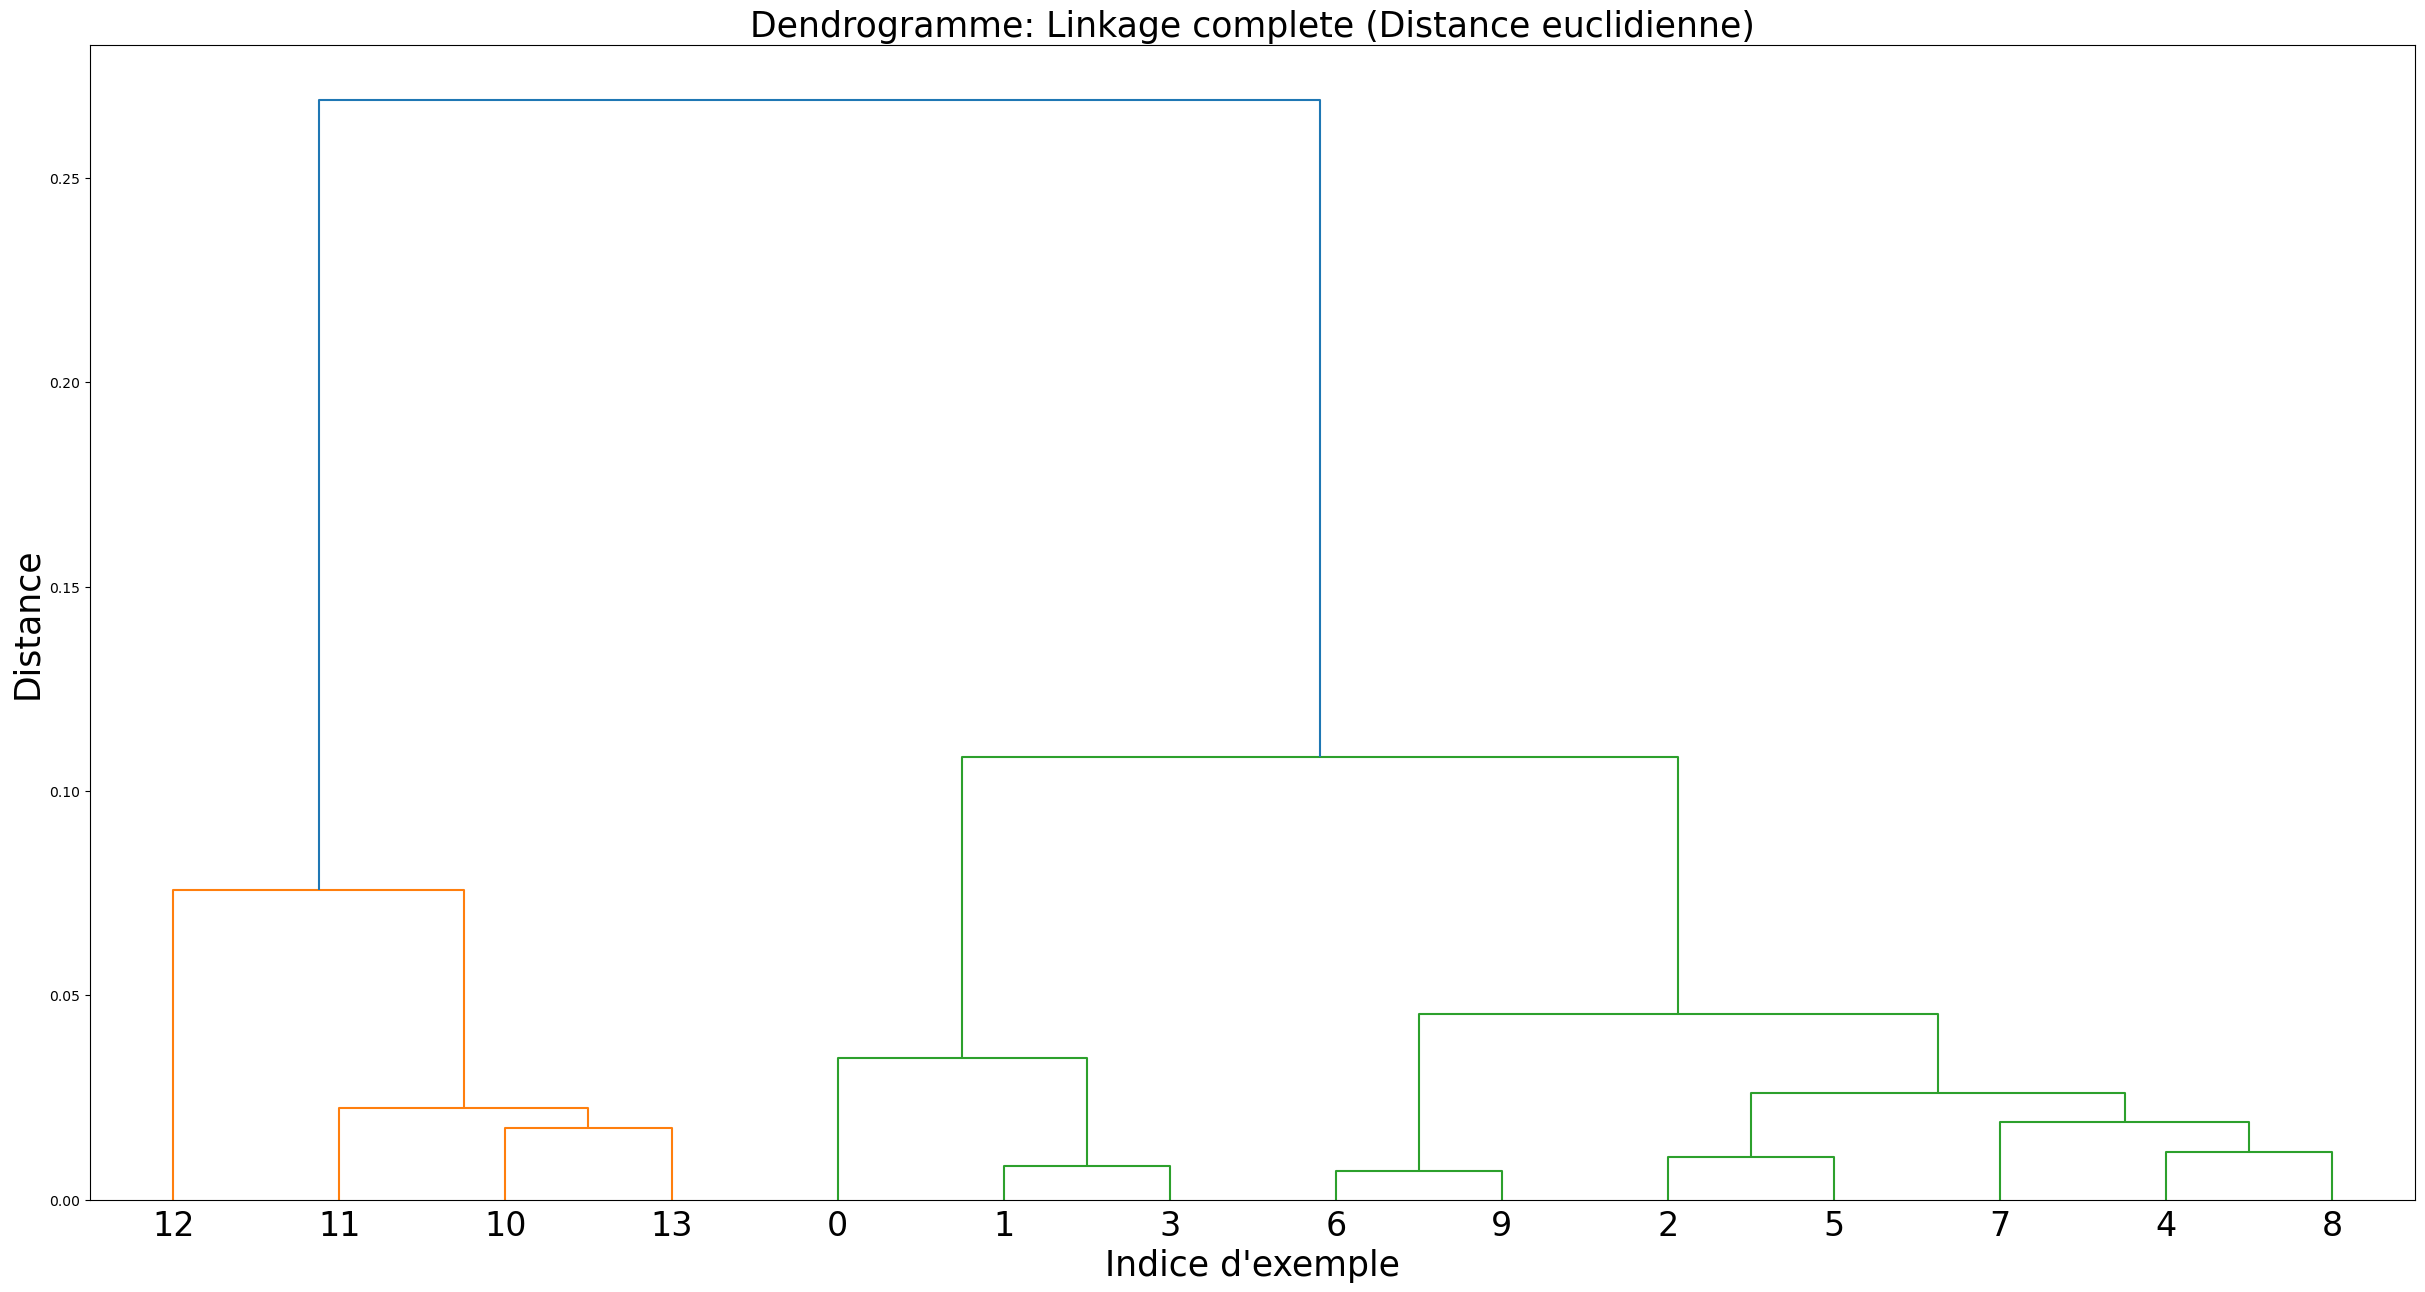

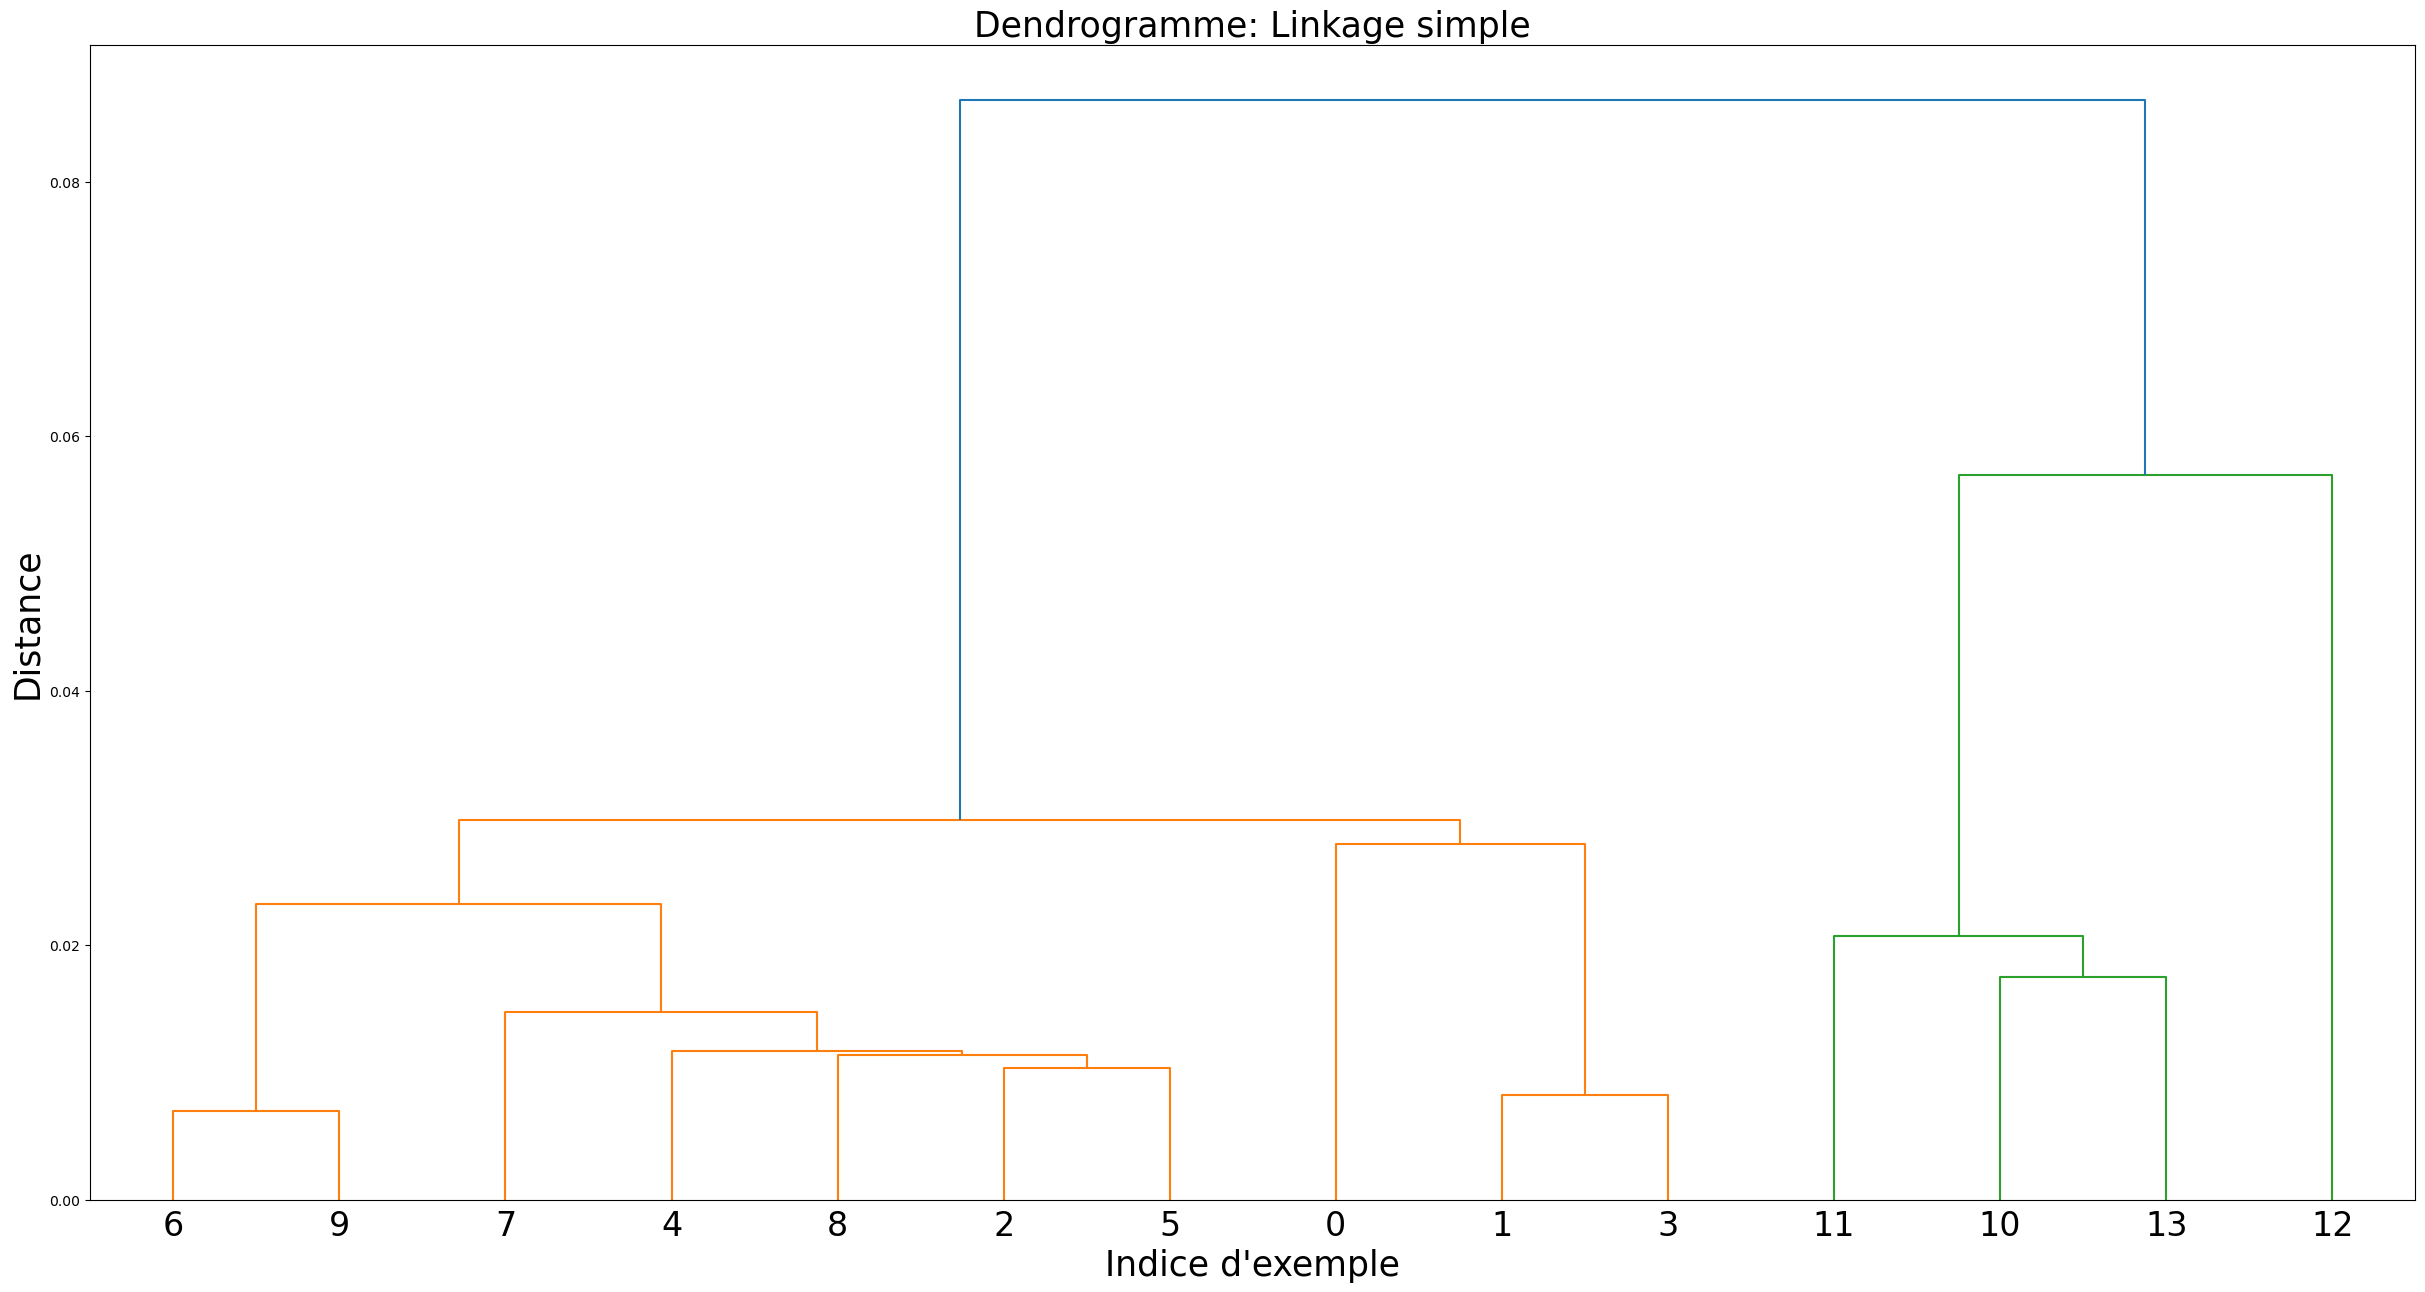

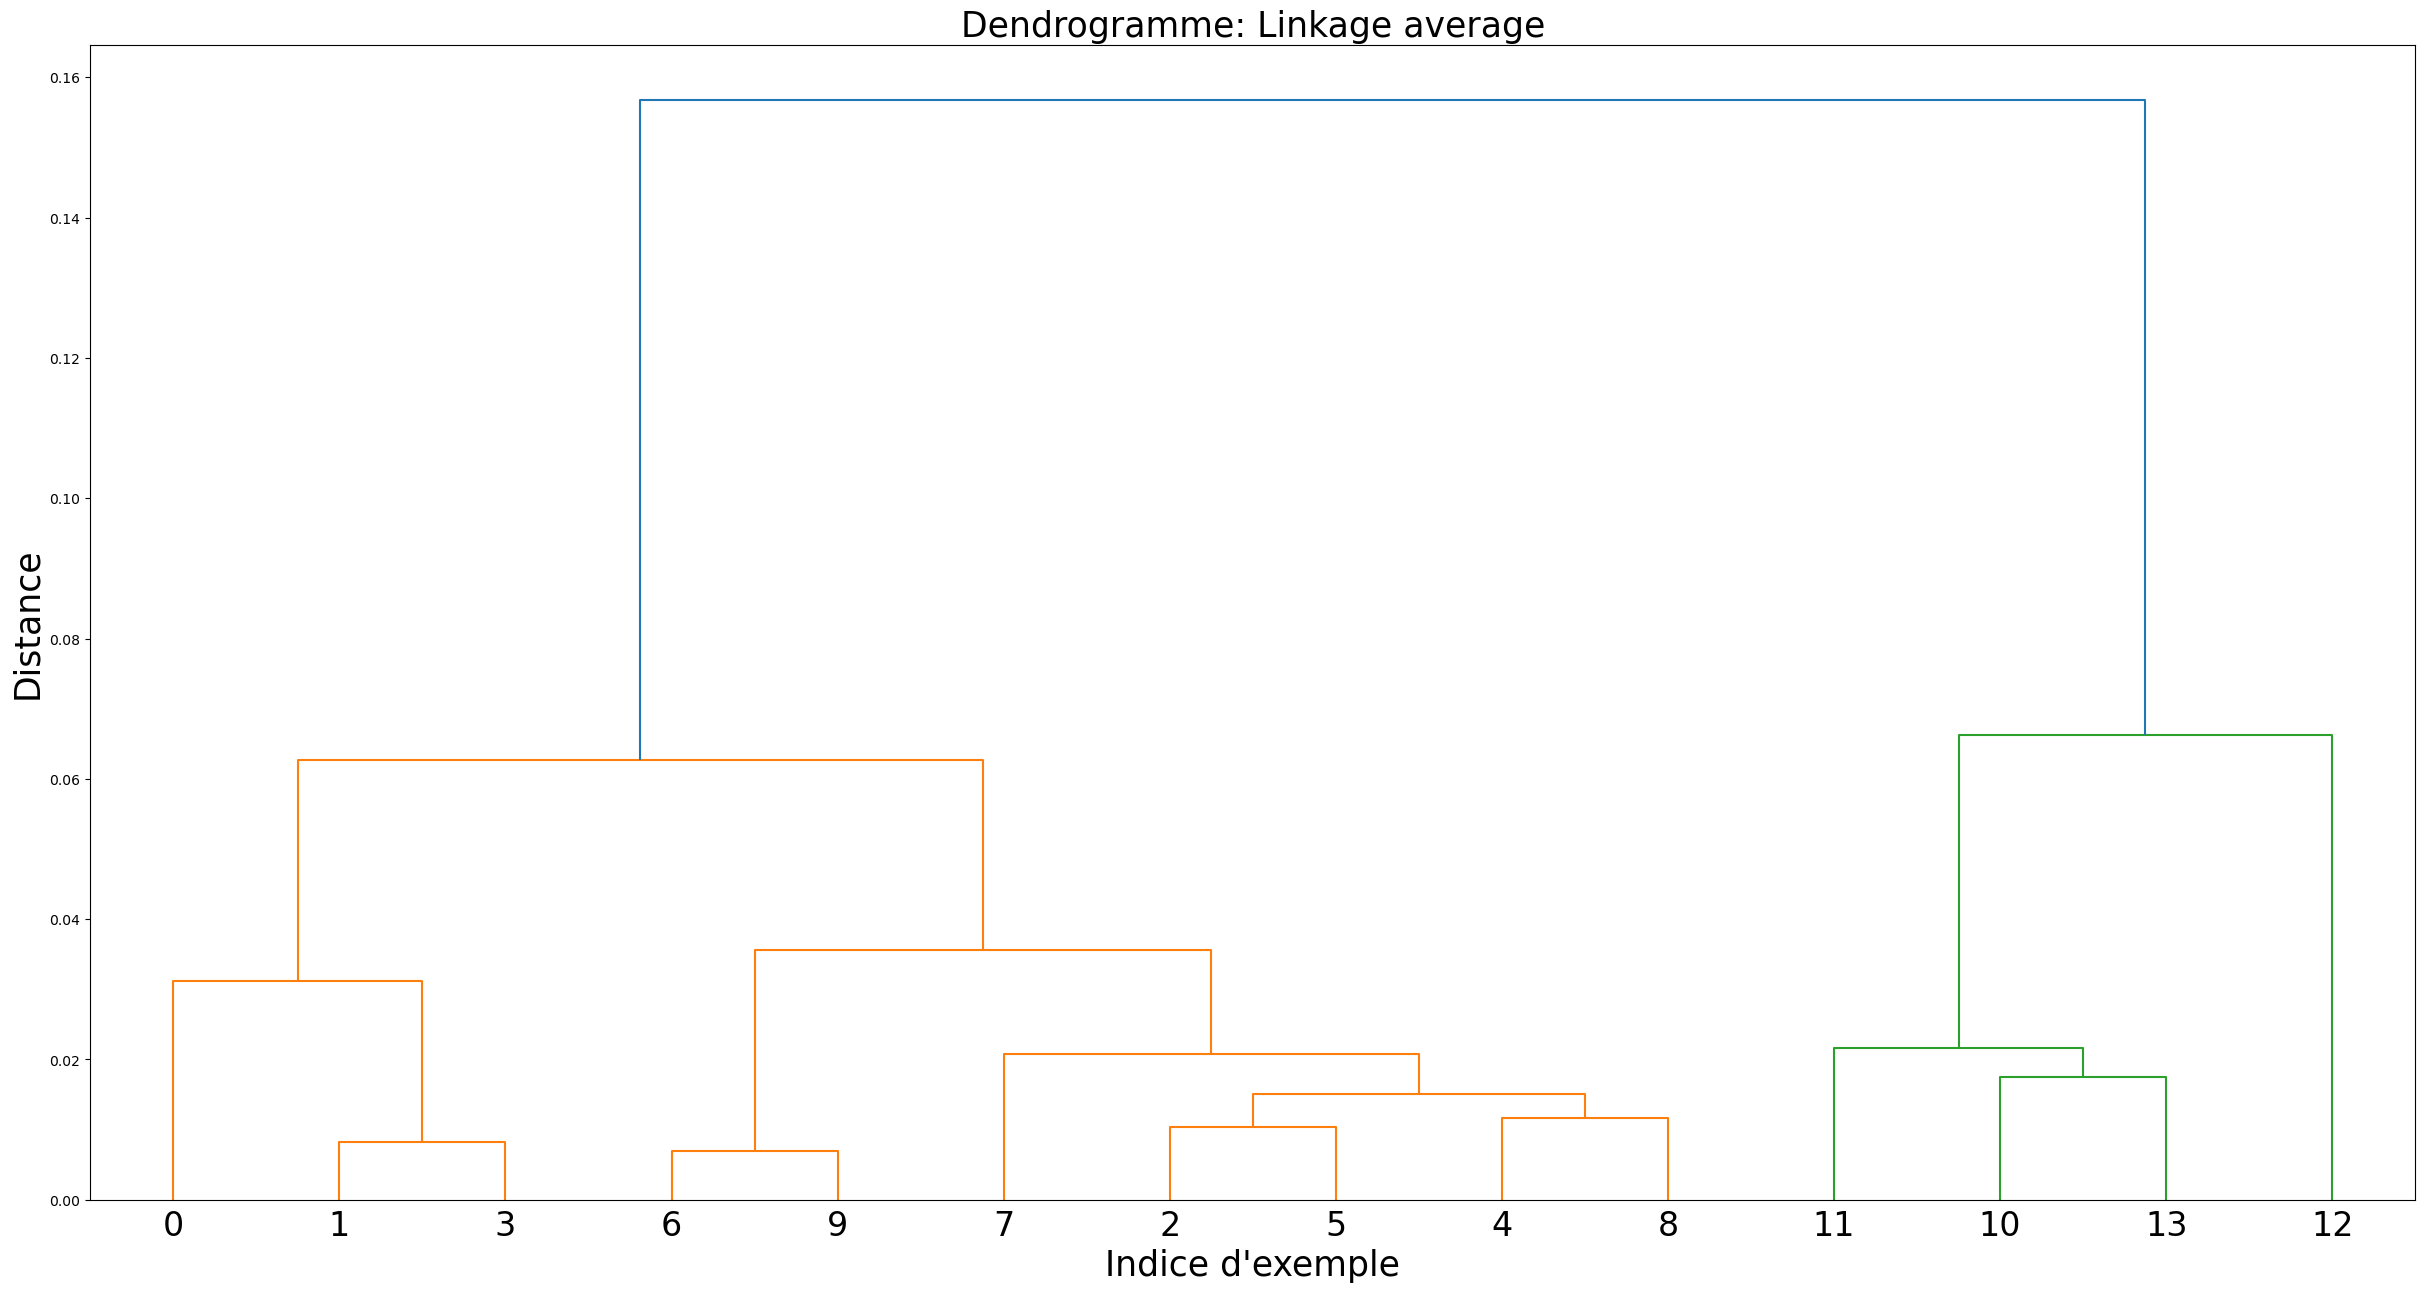

In [ ]:
les_linkages = [LinkageComplete(), LinkageSimple(), LinkageAverage(), LinkageCentroide()]

for link in les_linkages:
    CHA_dendrogramme(CHA_algorithme(data_Paris_norm,link,verbose=False),link)
